The observational campaign of FAST (Zhang et al) was between : 2024 January 28 to 2024 August 29 (UT).
In MJD this is : 60337 - 60551
We make this 60337,60552 to include the day of 60551

In order to compare observational campaigns of NRT and HyperFlash we use these dates for the cumulative energy distributions.

In [1]:
#General packages, powerlaw is vital for this analysis
import numpy as np
import numpy.ma as ma
from tqdm import tqdm
import random
import pandas as pd
import powerlaw

#Matplotlib packages
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib import rcParams
from matplotlib import transforms
import matplotlib.patheffects as pe

#Scipy packages 
from scipy.optimize import curve_fit
from scipy.stats import chi2
import scipy.optimize as spopt

#Astropy packages
from astropy import units as u
from astropy.cosmology import Planck15 as cosmo

# #Figure settings
import matplotlib
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

import frb_functions

In [2]:
def pl_dist_pdf(x, x_min, ind):
    """PDF of power law distribution"""
    return (ind - 1) * (x/x_min)**-ind / x_min

In [3]:
def get_rate_errors(bursts, conf_level=0.90):
    low_lim, upp_lim = get_poisson_error(bursts, conf_level=conf_level)
    # if no bursts are detected, get single sided upper limit as rate 
    lim = bursts == 0

    new_conf_level = 1 - ( (1-conf_level)*2 ) # for single sided upper limit 
    _, upp_lim[lim] = get_poisson_error(np.array([0]), conf_level=new_conf_level)
    
    dx_upp = upp_lim - bursts
    dx_low = bursts - low_lim

    return dx_low, dx_upp 

In [4]:
def get_poisson_error(r, conf_level=0.68):
    """
    adapted from Gehrels et al. 1986
    example use:
    rate = np.array([1,2,3,10])
    get_poisson_error(rate, conf_level=0.68) # returns 1-sigma lower and upper limit on the rate
    
    can be used to get the lower and upper limits for burst rate. 
    If bursts_obserrved = 0, it becomes a one sided distrubution, wherein conf_level_onesided = 1 - (1-conf_level)*2 
    """
    low_lim = 0.5 * chi2.ppf((1 - conf_level) / 2, 2 * r)
    low_lim[np.isnan(low_lim)] = 0 
    upp_lim = 0.5 * chi2.ppf((1 + conf_level) / 2, 2 * (r+1))
    upp_lim[np.isnan(upp_lim)] = 0
    
    return low_lim, upp_lim

In [5]:
def fast_zhang_2024(csv_file):
    """
    Read in csv FAST .csv file  
    from: https://ui.adsabs.harvard.edu/abs/2025arXiv250714707Z/abstract
    host: https://doi.org/10.57760/sciencedb.Fastro.00030
    """

    #Read CSV normally (don't set index_col)
    fast_csv = pd.read_csv(csv_file, sep=",", header=0, na_values='NA', index_col=0)
    
    # Rename measurement columns only (keep BurstID and Date as-is)
    fast_csv = fast_csv.rename(columns={
        "MJD(topo@1.5GHz)": "MJD",
        "DM(pc/cc)": "DM",
        "DM_err(pc/cc)": "DMError",
        "Weff(ms)": "width",
        "Weff_err(ms)": "widtherror",
        "Flux(mJy)": "flux",
        "Flux_err(mJy)": "fluxerror",
        "Bandwidth(MHz)": "bandwidth",
        "Bandwidth_err(MHz)": "bandwidtherror",
        "Fluence(mJy ms)": "fluence_mJyms",
        "Fluence_err(mJy ms)": "fluenceerror",
        "Energy(erg)": "energy",
        "Energy_err(erg)": "energyerror",
        "Center_Freq.(MHz)": "feakfrequency",
        "Center_Freq_err(MHz)": "feakfrequencyerror"
    })
    
    # Filter by MJD
    #mjd_begin = 59869
    #mjd_end = 59910
    #fast_csv = fast_csv[fast_csv['MJD'].between(mjd_begin, mjd_end)]
    
    # Display dataframe
    display(fast_csv)
    
    # Return fluence and full dataframe (BurstID included)
    fluence = fast_csv['fluence_mJyms'].values / 1_000

    return fluence, fast_csv
    
fast_fluence_r147, fast_csv = fast_zhang_2024(csv_file="../databases/fast_zhang_2025/FRB20240114A_SuppTab2_saturation_tag.csv")  

,BurstID,Date,MJD,MJD(bary@inf freq.),DM,DMError,width,widtherror,flux,fluxerror,...,Upper_freq_err(MHz),Tsamp(s),Nchan,fluence_mJyms,fluenceerror,energy,energyerror,note,bestfit,saturation_tag
0,B00001,20240128,60337.238280,60337.234184,529.5,0.1,3.51,0.23,217.48,9.57,...,5.8,0.000197,4096,764.10,61.05,6.117930e+37,5.979520e+36,NaN,Gaussian,False
1,B00002,20240128,60337.240239,60337.236143,529.6,0.8,2.60,0.43,86.47,3.81,...,6.9,0.000197,4096,224.77,38.88,7.196810e+36,1.466040e+36,NaN,CDF,False
2,B00003,20240128,60337.241530,60337.237434,525.0,0.3,4.63,1.23,18.15,0.95,...,35.6,0.000197,4096,84.01,22.77,1.269590e+37,4.199310e+36,NaN,Gaussian,False
3,B00004,20240128,60337.243759,60337.239663,526.7,2,2.66,0.49,74.30,3.33,...,4.7,0.000197,4096,197.63,37.69,6.201740e+36,1.266920e+36,NaN,CDF,False
4,B00005,20240128,60337.243836,60337.239740,527.0,2.2,1.20,0.26,77.42,3.59,...,2.2,0.000197,4096,93.21,20.58,4.137900e+36,9.265410e+35,NaN,Gaussian,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11548,B11549,20240830,60551.711875,60551.718359,533.2,0.7,3.22,0.35,42.10,3.54,...,2.6,0.000049,4096,135.46,18.55,9.884280e+36,1.379980e+36,NaN,Gaussian,False
11549,B11550,20240830,60551.712392,60551.718876,529.3,0.5,2.55,0.52,17.94,1.55,...,14.0,0.000049,4096,45.80,10.09,9.357970e+36,2.120070e+36,NaN,Gaussian,False
11550,B11551,20240830,60551.712486,60551.718970,528.3,1.5,2.53,0.54,29.90,2.60,...,5.9,0.000049,4096,75.64,17.39,3.714680e+36,8.806030e+35,NaN,CDF,False
11551,B11552,20240830,60551.712593,60551.719077,533.2,0.2,5.73,0.39,63.96,5.95,...,9.5,0.000049,4096,366.41,42.07,5.303470e+37,6.313060e+36,NaN,CDF,False


In [6]:
km40_fluence_r147 = np.array([190,151,160,230,270,66,101,86])

In [7]:
np.min(fast_csv["fluence_mJyms"].values)/1000

0.023260000000000003

In [8]:
def nancay(csv_file, mjd_limit=True,mjd_limit_2=False):
    """
    Function to import the fluences for the NRT sample

    TODO: perhaps add a simple differential distirbution on Fluences?
    """
    
    nancay_df = pd.read_csv(csv_file, on_bad_lines='skip', header=0, sep=',')
    nancay_df = nancay_df.sort_values(by="MJD_at_peak")
    display(nancay_df)
    
    mjds = nancay_df['MJD_at_peak'].values
    print(f"The first burst by NRT was detected on {np.min(mjds):.3f}")
    print(f"The last burst by NRT was detected on {np.max(mjds):.3f}")
    
    if mjd_limit ==True:
        #These dates are the entire campaign for now
        mjd_begin = 60337
        mjd_end = 60552
        nancay_df = nancay_df[nancay_df['MJD_at_peak'].between(mjd_begin, mjd_end)]
    elif mjd_limit_2 == True:
        mjd_begin = 60337
        mjd_end = 60723
        nancay_df = nancay_df[nancay_df['MJD_at_peak'].between(mjd_begin, mjd_end)]
        
    fluences = nancay_df['fluence_Jyms'].values

    #Filter on Fluences that have
    zero_fluences = fluences[fluences < 0]
    print(f"The array with Fluences below zero: {zero_fluences}")

    #Fail safe filter on Fluences -- This does nothing in the final csv file
    fluences = fluences[fluences >= 0]

    print(f"There are {len(fluences)} bursts in this sample")
    return fluences

nrt_fluence_r147 = nancay(csv_file="../databases/NRT_burst_properties_Lband.csv",\
                                 mjd_limit=True)

,burst_name,DM,MJD_at_peak,peak_positions_ms,peak_flux,fluence_Jyms,iso_E,event_duration_ms,1D_Gaussian_fits,acf_fits,spectral_extent_MHz,mask,bad_fit?,special?,integrated_s/n
0,burst_60346.492562754625s1p3t105.422,527.7,60346.492563,"[52.928, 61.55199999999999]",3.815373,19.830658,NaN,15.872,"[array([15.43367484, 53.23817381, 1.33095611,...",NaN,304.0,[106. 111. 112. 81. 80. 79. 78. 76. 75. ...,False,True,[-6.51174024e-01 2.30571080e+00 1.42962642e-...
2,burst_60350.4878707705s2p2t92.1835,529.0,60350.487871,[50.608],0.842451,0.912145,NaN,6.944,"[array([ 1.60624205, 50.79790355, 0.95099225,...",[5.50047627e+04 5.50960000e+01 1.48600000e+03 ...,252.0,[104. 103. 0. 15. 33. 78. 81. 98. 99. ...,False,False,[-4.33978419e-02 -2.05210751e-01 -1.53581807e+...
1,burst_60350.49398941139s3p1t69.983,529.0,60350.493989,[51.151999999999994],0.842573,0.671462,NaN,8.640,"[array([6.12755948e+00, 5.25500174e+01, 1.9875...",[2.36281816e+04 5.30000000e+01 1.48600000e+03 ...,180.0,[112. 0. 24. 11. 79. 78. 103. 106. 111. ...,gaussian,False,[ 1.84642018e-01 -1.03971388e+00 2.41934636e-...
4,burst_60352.48971259889s3p2t52.4664,528.0,60352.489713,[50.976],2.785855,2.192981,NaN,2.416,"[array([11.19735425, 50.86710855, 0.35170964,...",[1.33926724e+04 5.18480002e+01 1.48601512e+03 ...,324.0,[ 0. 16. 99. 97. 98. 112. 110. 111.],False,False,[ 1.19560483e+00 -5.71263356e-02 -1.30188943e-...
3,burst_60352.49256452829s3p4t58.8731,530.0,60352.492565,"[50.208, 43.215999999999994]",0.823606,1.197239,NaN,11.264,"[array([3.25610934e+00, 4.19244594e+01, 1.3412...",[5.05069274e+04 4.97679927e+01 1.48599975e+03 ...,304.0,[ 99. 98. 97. 112. 111. 106. 0. 82. 84. ...,both,True,[-0.10273355 0.16483473 -1.30951955 -0.513911...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,burst_60715.52104541884s5p2t75.9199_500ms,530.0,60715.521046,[66.35199999999999],0.634291,1.023986,NaN,15.776,"[array([5.93435451e+00, 6.68021490e+01, 4.4175...",NaN,132.0,[ 0. 32. 33. 81. 82. 75. 76. 78. 80. ...,gaussian,False,[ 1.37015157e+00 -3.24630697e-01 1.35387352e+...
671,burst_60722.462425032405s1p2t75.5228_500ms,530.0,60722.462425,[50.016],0.721068,0.766984,NaN,7.504,[],NaN,280.0,[ 0. 103. 110. 112. 111. 99. 98. 80. 78. ...,gaussian,False,[-1.51391039e+00 -1.60684943e+00 8.93371622e-...
672,burst_60722.4626088993s1p2t91.4089_500ms,530.0,60722.462609,[50.064],1.018085,1.807762,NaN,12.944,"[array([4.52317881e+00, 5.21688293e+01, 2.0015...",NaN,284.0,[ 0. 98. 99. 103. 112. 111. 79. 78. 77. ...,gaussian,False,[ 4.60389013e-01 3.03294279e-01 -1.45882508e+...
674,burst_60722.46767566667s1p6t49.1776_500ms,530.0,60722.467676,[57.10399999999999],0.768910,2.210698,NaN,26.432,"[array([3.51615973e+00, 5.70475053e+01, 8.3358...",NaN,380.0,[ 0. 79. 76. 77. 78. 98. 99. 111. 112.],gaussian,False,[-0.35603605 0.91593591 0.15212259 ... 1.52...


The first burst by NRT was detected on 60346.493
The last burst by NRT was detected on 60722.469
The array with Fluences below zero: [-1.73780712 -1.53612537]
There are 468 bursts in this sample


In [9]:
nrt_fluence_r147_check = nancay(csv_file="../databases/NRT_burst_properties_Lband.csv",\
                                 mjd_limit=False)

,burst_name,DM,MJD_at_peak,peak_positions_ms,peak_flux,fluence_Jyms,iso_E,event_duration_ms,1D_Gaussian_fits,acf_fits,spectral_extent_MHz,mask,bad_fit?,special?,integrated_s/n
0,burst_60346.492562754625s1p3t105.422,527.7,60346.492563,"[52.928, 61.55199999999999]",3.815373,19.830658,NaN,15.872,"[array([15.43367484, 53.23817381, 1.33095611,...",NaN,304.0,[106. 111. 112. 81. 80. 79. 78. 76. 75. ...,False,True,[-6.51174024e-01 2.30571080e+00 1.42962642e-...
2,burst_60350.4878707705s2p2t92.1835,529.0,60350.487871,[50.608],0.842451,0.912145,NaN,6.944,"[array([ 1.60624205, 50.79790355, 0.95099225,...",[5.50047627e+04 5.50960000e+01 1.48600000e+03 ...,252.0,[104. 103. 0. 15. 33. 78. 81. 98. 99. ...,False,False,[-4.33978419e-02 -2.05210751e-01 -1.53581807e+...
1,burst_60350.49398941139s3p1t69.983,529.0,60350.493989,[51.151999999999994],0.842573,0.671462,NaN,8.640,"[array([6.12755948e+00, 5.25500174e+01, 1.9875...",[2.36281816e+04 5.30000000e+01 1.48600000e+03 ...,180.0,[112. 0. 24. 11. 79. 78. 103. 106. 111. ...,gaussian,False,[ 1.84642018e-01 -1.03971388e+00 2.41934636e-...
4,burst_60352.48971259889s3p2t52.4664,528.0,60352.489713,[50.976],2.785855,2.192981,NaN,2.416,"[array([11.19735425, 50.86710855, 0.35170964,...",[1.33926724e+04 5.18480002e+01 1.48601512e+03 ...,324.0,[ 0. 16. 99. 97. 98. 112. 110. 111.],False,False,[ 1.19560483e+00 -5.71263356e-02 -1.30188943e-...
3,burst_60352.49256452829s3p4t58.8731,530.0,60352.492565,"[50.208, 43.215999999999994]",0.823606,1.197239,NaN,11.264,"[array([3.25610934e+00, 4.19244594e+01, 1.3412...",[5.05069274e+04 4.97679927e+01 1.48599975e+03 ...,304.0,[ 99. 98. 97. 112. 111. 106. 0. 82. 84. ...,both,True,[-0.10273355 0.16483473 -1.30951955 -0.513911...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,burst_60715.52104541884s5p2t75.9199_500ms,530.0,60715.521046,[66.35199999999999],0.634291,1.023986,NaN,15.776,"[array([5.93435451e+00, 6.68021490e+01, 4.4175...",NaN,132.0,[ 0. 32. 33. 81. 82. 75. 76. 78. 80. ...,gaussian,False,[ 1.37015157e+00 -3.24630697e-01 1.35387352e+...
671,burst_60722.462425032405s1p2t75.5228_500ms,530.0,60722.462425,[50.016],0.721068,0.766984,NaN,7.504,[],NaN,280.0,[ 0. 103. 110. 112. 111. 99. 98. 80. 78. ...,gaussian,False,[-1.51391039e+00 -1.60684943e+00 8.93371622e-...
672,burst_60722.4626088993s1p2t91.4089_500ms,530.0,60722.462609,[50.064],1.018085,1.807762,NaN,12.944,"[array([4.52317881e+00, 5.21688293e+01, 2.0015...",NaN,284.0,[ 0. 98. 99. 103. 112. 111. 79. 78. 77. ...,gaussian,False,[ 4.60389013e-01 3.03294279e-01 -1.45882508e+...
674,burst_60722.46767566667s1p6t49.1776_500ms,530.0,60722.467676,[57.10399999999999],0.768910,2.210698,NaN,26.432,"[array([3.51615973e+00, 5.70475053e+01, 8.3358...",NaN,380.0,[ 0. 79. 76. 77. 78. 98. 99. 111. 112.],gaussian,False,[-0.35603605 0.91593591 0.15212259 ... 1.52...


The first burst by NRT was detected on 60346.493
The last burst by NRT was detected on 60722.469
The array with Fluences below zero: [-1.73780712 -1.53612537]
There are 673 bursts in this sample


In [10]:
def fluence_limit(sefd=420, width=1, bw=100, snr=20):
    '''
    sefd in Jy, width in ms, bw in MHz
    '''
    fluence_limit = snr * sefd * np.sqrt( (width/1000.) / (2 * bw * 1e6))
    # return things in Jy~ms
    return fluence_limit * 1000

In [11]:
def fluence_hyperflash_loader(csv_file, band="L", mjd_limit=False, telescope=None):

    fluence_df = pd.read_csv(csv_file, index_col=0)

    fluence_df = fluence_df[["id", "toa", "fluence", "bandwidth", "central frequency", "2bit-wb-tag"]].rename(columns={"central frequency": "cent_freq"})
    fluence_df = fluence_df.dropna(subset=["toa"])

    fluence_df["burst-index"] = fluence_df['id'].str.split('-').str[0].str[1:].astype(int)
    fluence_df["telescope"] = fluence_df['id'].str.split('-').str[1].astype(str)

    ##Method to filter on telescope: wb, tr, st, o8
    if telescope is not None:
        try:
            fluence_df = fluence_df[fluence_df["telescope"] == telescope]
        except KeyError:
            print("Warning: 'telescope' column not found. Skipping filter.")

    if mjd_limit ==True:
        mjd_begin = 60337
        mjd_end = 60552
        fluence_df = fluence_df[fluence_df['toa'].between(mjd_begin, mjd_end)]

    if band == "L":
        fluence_df = fluence_df[fluence_df["cent_freq"] > 1000]
    elif band == "P": 
        fluence_df = fluence_df[fluence_df["cent_freq"] < 1000]
        
    fluence_df = fluence_df.sort_values(by=['toa'])
    fluence_df = fluence_df.reset_index(drop=True)

    return fluence_df

full_hyperflash_db = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", mjd_limit=True)

full_hyperflash_db_no_dupl = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmax()]
full_hyperflash_db_no_dupl_arr = full_hyperflash_db_no_dupl['fluence'].values
print(full_hyperflash_db_no_dupl_arr)
full_hyperflash_db_no_dupl_arr[::-1].sort()

full_hyperflash_db_no_dupl_lw = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmin()]
full_hyperflash_db_no_dupl_lw_arr = full_hyperflash_db_no_dupl_lw['fluence'].values
print(full_hyperflash_db_no_dupl_lw_arr)
full_hyperflash_db_no_dupl_lw_arr[::-1].sort()
print(np.max(full_hyperflash_db_no_dupl_lw_arr))

[  16.66   20.15   25.1    35.49   16.72   17.45   12.74    7.34   16.21
    8.67   15.48   42.4    11.13   11.29   14.52   11.49   15.4    22.15
   20.95   50.08   28.42   29.34   17.27   21.19   26.11   17.39   31.05
   32.37   42.07   16.15   10.33   17.17   21.13   42.42   36.76   35.93
  117.6    25.97   20.77   26.76   12.48   21.39  210.7    12.92   19.62
   25.16   14.75   23.6    16.72   12.1    30.96   28.46   37.3    31.86
   87.03   20.79   53.35  668.94   23.85  144.71  194.56   15.19    7.09
   28.53   24.11    5.78    9.16   17.37    5.25   42.19   27.55   27.39
   30.41   17.47   11.82    8.18  132.58    8.32    8.53   10.1    11.65
    9.65   32.88   16.37    4.67   13.24    5.07    9.18   15.01    8.97
   20.07   17.78   11.16   16.84    5.3    31.78   20.92  530.21   22.84
   81.12    7.96   50.6    14.24   11.55   10.14   23.71   18.82   54.03
   12.49   14.54   39.2    16.14   23.86   52.71  137.86   13.44   12.45
   13.36 1168.39   36.38   21.31   13.81   25.15   

In [12]:
fluence_df_wb_l = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", \
                                          telescope="wb", mjd_limit=False, band="L")

fluence_df_wb_p = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", \
                                          telescope="wb", mjd_limit=True, band="P")

fluence_df_st = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", \
                                          telescope="st", mjd_limit=False, band="L")

fluence_df_o8 = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", \
                                          telescope="o8", mjd_limit=False, band="L")

fluence_df_tr = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", \
                                          telescope="tr", mjd_limit=False, band="L")

In [13]:
def fluences_arrays(df_fluences, telescope):
    "return Fluences arrays from different activity windows"

    #Westerbork
    fluences = df_fluences[df_fluences['telescope'] == telescope]
    fluences_arr = fluences['fluence'].values
    fluences_arr[::-1].sort()

    print(f'{telescope} : {len(fluences_arr)}')
    return fluences_arr

fluences_wb_arr = fluences_arrays(full_hyperflash_db, telescope='wb')
fluences_stk_arr = fluences_arrays(full_hyperflash_db, telescope='st')
fluences_tr_arr = fluences_arrays(full_hyperflash_db, telescope='tr')
fluences_o8_arr = fluences_arrays(full_hyperflash_db, telescope='o8')

fluences_all = np.concatenate([
    fluences_wb_arr,
    fluences_stk_arr,
    fluences_tr_arr,
    fluences_o8_arr
])

wb : 32
st : 68
tr : 12
o8 : 46


In [14]:
def func_broken_powerlaw(x, scale=1, gamma1=1, gamma2=1, ebreak=1):

    return np.piecewise(x, 
                        [x < ebreak, x >= ebreak],
                        [lambda x: scale * (x/ebreak)**gamma1, lambda x: scale * (x/ebreak)**gamma2])

# def breakpoint_nancay(fluences, obs_h):

#     ############
#     #Double Powerlaw
#     ############
    
#     #Apply a broken powerlaw fit to the data to find the breakpoint
#     #Next we will seperately fit 2 powerlaws to the data in order to take into account error propagation
#     #This seems dirty, and it is, but that is what you get 
    
#     #Energy is sorted from high-low
    
#     energies_arr = fluences
#     energies_arr.sort()
    
#     pw_results = powerlaw.Fit(energies_arr)
#     print("Turning point:", pw_results.xmin, "jy ms")

#     energies_fit_p = energies_arr[energies_arr>=pw_results.xmin]
#     y_points_fit = np.arange(1, len(energies_fit_p)+1, 1) / obs_h
#     popt2, pcov2 = curve_fit(func_broken_powerlaw, np.sort(energies_fit_p), np.flip(y_points_fit),
#                            p0 = np.asarray([0.2, -1.8,-0.4,20]), maxfev=50000)

#     breakpoint = popt2[-1]
    
#     print(f"breakpoint of the double powerlaw: {breakpoint:.2f} jy ms")

#     ### Simple diagnostic tool
#     # I used this plotting code snippet to confirm if the fit went alright.
#     # 25-Apr-24
#     plt.figure()
#     plt.plot(energies_fit_p,func_broken_powerlaw(energies_fit_p,*popt2),color='black',lw=1.5)
#     plt.scatter(np.sort(energies_fit_p), np.flip(y_points_fit), color='black', marker="^", s=10)
#     plt.xscale('log')
#     plt.yscale('log')
#     plt.show()
#     print("Due to the number of datapoints this first estimate can not be trusted")
#     ####

#     return breakpoint

# breakpoint_nancay(fluences=nrt_fluence_mkt, obs_h=5.54)

In [15]:
# Function to calculate energy per Hz at a given redshift (z)
def isotropic_energies(fluences_jy_ms, dist_mpc=616, z=0.130287):
    
    # Convert fluence from Jy·ms to Jy·s
    fluence_jys = np.array(fluences_jy_ms) * 1e-3  # Jy·s
    
    # Convert the distance from megaparsec to cm
    dis = 1.0 * u.megaparsec
    megap_cm = dis.to(u.cm).value

    #mpc to cm
    distance_lum_cm = megap_cm*dist_mpc

    #Redshift correction, see Macquart and Eckers for the function
    red_cor = 1 / (1 + z)**2

    # calculate energy per Hz
    energy_specific = fluence_jys * 4*np.pi*(distance_lum_cm**2) * 1e-23 * red_cor
    
    return energy_specific

In [16]:
def energy_to_fluence(energies, distance=616,z=0.130287):
    """Convert isotropic energies to fluences"""
    "Needed for the inverse calculation for a secondary axis"
    # Convert distance from Mpc to cm
    dis = 1.0 * u.megaparsec
    megap_cm = dis.to(u.cm).value
    distance_lum_cm = megap_cm * distance

    # Apply redshift correction
    red_cor = 1 / (1 + z)**2

    # Calculate fluence in Jy ms
    fluence_jys = energies / (4 * np.pi * (distance_lum_cm**2) * 1e-23 * red_cor)
    fluences = fluence_jys * 1e3  # Convert from Jy s to Jy ms
    return fluences

In [17]:
def func_powerlaw(x, scale=1, gamma=1):
    return x**gamma * scale

In [18]:
def slope_est(energies_array, conf_level=1):
    """
    Function to do a first order estimate of the slope and error
    method used in papers from Hewitt, Nimmo and Kirsten
    
    essentially eq 3 from this paper:
    link: https://ui.adsabs.harvard.edu/abs/2019MNRAS.483.1342J/abstract
    """

    energies_array.sort()
    M=len(energies_array)
    si=np.array(energies_array)/energies_array[0]

    corrfact=(M-1)/M
    a_star=corrfact*1/( (-1/M) * np.sum(np.log(si)) )
    err= M*a_star / ( (M-1)*(M-2)**0.5 )
    
    if conf_level == 2:
        err = err * 2

    return a_star,err

In [19]:
def gamma_slopes(energies_arr, conf_level=1):
    """
    Iterativly refit a best slope guess for a powerlaw distribution by removing points
    The errors at 2-sigma, since we multiply by 2 in the error
    """
    
    energies_arr.sort()
    total_gamma = []
    energy_threshold = []
    error_ar = []

    for j in range(1,len(energies_arr)-1):
        alpha = (1/( -1/len(energies_arr[energies_arr>energies_arr[j]]) * \
                    np.sum(np.log(energies_arr[energies_arr>energies_arr[j]] / energies_arr[j]))))
        M = len(energies_arr[energies_arr>energies_arr[j]])
        
        alpha = ((M-1)/M) * alpha
        total_gamma.append(alpha)
        energy_threshold.append(energies_arr[j])

        if M > 2:
        #We multiply by 2 to convert the 1-sigma error to 2 sigma errors
            error = M * alpha / ((M-1)*(M-2)**0.5) 
            
            if conf_level == 2:
                error = error * 2
        
            error_ar.append(error)
            
    return total_gamma, energy_threshold, error_ar

In [20]:
def power_law_fit(energies, observed_time, scale=1, limit=(1, 1),
                  limit_b=False, fit=True, ignore_turnover=False,
                  time_is_weights=False, ex_max=None):
    "Function to return the fitted powerlaw to the datapoints"

    energies.sort()
    if fit:
        #Determine the turning point in the powerlaw with the Powerlaw module -- From the powerlaw paper:
        #The search for the optimal xmin can also be restricted to a range, given as a tuple or list:
        #if xmin is two values, powerlaw will search for a turnover points between these values
        if not limit_b:
            pw_results = powerlaw.Fit(energies)
            turning_point_fluence = energy_to_fluence(pw_results.xmin)
            print(f"Turning point: {pw_results.xmin:.2e} energy units or fluence: {turning_point_fluence:.2f} Jy ms")
        else:
            pw_results = powerlaw.Fit(energies,  xmin=(limit[0],limit[1]))#, xmax=limit[1])
            turning_point_fluence = energy_to_fluence(pw_results.xmin)
            print(f"No limit_b, Turning point: {pw_results.xmin:.2e} energy units or fluence: {turning_point_fluence:.2f} Jy ms")
        if ignore_turnover:
            pw_results.xmin = limit[0]

        print(f"pw xmin: {pw_results.xmin:.2e}, xmax: {pw_results.xmax}")

        #Values that will be included in the fit
        energies_fit = energies[energies>=pw_results.xmin]

        #Values that are excluded in the fit
        energies_ex = energies[energies<pw_results.xmin]

        if not time_is_weights:
            #The burst rate, devide by the observed_time to get a rate per hours
            #ypoints for the fitted data
            y_points_fit = np.arange(1, len(energies_fit)+1, 1) / observed_time

            #ypoints for the not fitted data; scaled
            y_points_ex = np.arange(len(energies_fit)+1,
                                    len(energies_fit)+len(energies_ex)+1, 1) / observed_time
        else:
            y_points_fit = observed_time
            y_points_ex = []
            
        ###
        #Curve_fit for the slope estimate; this is just a first guess
        a_star, a_err = slope_est(energies)
        print(f"estimate using the a_star method: {a_star:.3f} {a_err:.3f}")
        ###

        # Functionality to exclude points in the high energy tail
        if ex_max is not None:
            print(f"ex_max = {ex_max}")
            print(f"Excluding max_energy; cutting off the last {ex_max} points")
        
            # Make copies of the original arrays before modifying them
            original_energies_fit = energies_fit.copy()
            original_y_points_fit = y_points_fit.copy()
        
            # Determine how many points to include and skip
            skip_burst = ex_max
            included = len(original_energies_fit) - skip_burst
        
            # Extract the excluded (high-energy) tail points
            ex_energies_high = original_energies_fit[included:]
            ex_y_points_high = original_y_points_fit[:skip_burst]
            print(f"Excluded coordinates: {ex_energies_high}, {ex_y_points_high}")

            #Making the expoints coordinates into 1 item to be returned
            ex_points_high = np.array([ex_energies_high, ex_y_points_high])
            
            # Truncate arrays to keep only the included data for fitting
            energies_fit = original_energies_fit[:included]
            y_points_fit = original_y_points_fit[skip_burst:]
            print(f"New FIT length: {len(energies_fit)}")

        else:
            ex_points_high = None
            
        #apply curve_fit to do the fit
        popt, pcov = curve_fit(func_powerlaw, energies_fit, np.flip(y_points_fit),
                               p0 = np.asarray([scale, a_star]), maxfev=50000)
        
        #flip x and y to use the x-error -- the multiply 0.2 is the 20% error on the energies
        popt_flip, pcov_flip = curve_fit(func_powerlaw, np.flip(y_points_fit),energies_fit,
                                         p0=[popt[0]**(1./-popt[1]), 1./popt[1]],
                                         sigma=np.asarray(energies_fit*0.2),\
                                         absolute_sigma=True)

        #Calculate the popt values in the xy frame, use the errors on the fit
        popt_back=[popt_flip[0]**(1./-popt_flip[1]), 1./popt_flip[1]]
        sol2 = [popt_back, pcov_flip]
        #print(sol2)
        print(sol2)
        sol2_err = np.sqrt(np.diag(sol2[1]))
        xx = np.linspace(np.min(energies_fit),np.max(energies_fit),500)
        p_y = func_powerlaw(xx, *sol2[0])

        ##Bootstrapping -- getting the variance on the error
        subset_int = int(len(energies_fit) * 0.9)
        print(f"Bootstrapping, only using {subset_int} points out of {len(energies_fit)} points")

        N=1000
        alpha_list = []
        for trial in tqdm(range(N)):

            #subset_list = random.sample(list(energies_fit), k = subset_int)

            #Get a random sample of 90% from the fitted energies
            ss_energie, ss_ypoint = zip(*random.sample(list(zip(energies_fit, y_points_fit)),
                                                       k=subset_int))

            #Sort them again from big to small
            ss_energie_1, ss_ypoint_1 = zip(*sorted(zip(ss_energie, ss_ypoint)))
            popt_bs_yx, pcov_bs_yx=curve_fit(func_powerlaw,np.flip(ss_ypoint_1),ss_energie_1,
                                             p0=[popt[0]**(1./-popt[1]),1./popt[1]],
                                             sigma=np.asarray(ss_energie_1)*0.2,absolute_sigma=True)

            #Covert back to values, bootstramp reversed
            popt_bs_r=[popt_bs_yx[0]**(1./-popt_bs_yx[1]),1./popt_bs_yx[1]]

            #Append the value for the slope the list
            alpha_list.append(popt_bs_r[1])

        #Calculate the boot_alpha
        boot_alpha = np.std(alpha_list)
        print(f"boot_alpha: {boot_alpha:.2f}")

        return energies_fit, y_points_fit, energies_ex, y_points_ex, \
            sol2, sol2_err, pw_results.xmin, boot_alpha, ex_points_high
    else:
        if not time_is_weights:
            y_points = np.arange(1, len(energies)+1, 1) / observed_time
        else:
            y_points = observed_time
            
        return energies, y_points

Calculating best minimal value for power law fit
Turning point: 5.74e+30 erg/Hz
breakpoint of the double powerlaw: 2.00e+31 erg/Hz


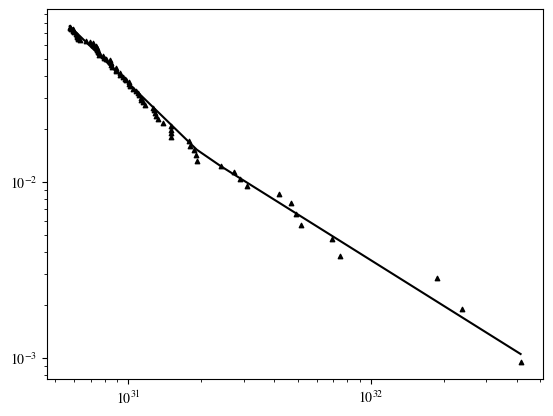

Slope below break (gamma1): -1.34 ± 0.02
Slope above break (gamma2): -0.86 ± 0.17


1.997526512080286e+31

In [21]:
def func_broken_powerlaw(x, scale=1, gamma1=1, gamma2=1, ebreak=1):

    return np.piecewise(x, 
                        [x < ebreak, x >= ebreak],
                        [lambda x: scale * (x/ebreak)**gamma1, lambda x: scale * (x/ebreak)**gamma2])

def breakpoint_calculator(fluences, obs_h):

    ############
    #Double Powerlaw
    ############
    energies_arr = isotropic_energies(fluences)
    energies_arr.sort()
    
    pw_results = powerlaw.Fit(energies_arr)
    print("Turning point:", f"{pw_results.xmin:.2e}", "erg/Hz")

    energies_fit_p = energies_arr[energies_arr>=pw_results.xmin]
    y_points_fit = np.arange(1, len(energies_fit_p)+1, 1) / obs_h
    popt2, pcov2 = curve_fit(func_broken_powerlaw, np.sort(energies_fit_p), np.flip(y_points_fit),
                           p0 = np.asarray([10, -1.8,-0.4,1e31]), maxfev=50000)

    breakpoint = popt2[-1]
    
    print(f"breakpoint of the double powerlaw: {breakpoint:.2e} erg/Hz")

    ### Simple diagnostic tool
    plt.figure()
    plt.plot(energies_fit_p,func_broken_powerlaw(energies_fit_p,*popt2),color='black',lw=1.5)
    plt.scatter(np.sort(energies_fit_p), np.flip(y_points_fit), color='black', marker="^", s=10)
    plt.xscale('log')
    plt.yscale('log')
    plt.show()
    ####

    gamma1 = popt2[1]
    gamma2 = popt2[2]
    
    gamma1_err = np.sqrt(pcov2[1, 1])
    gamma2_err = np.sqrt(pcov2[2, 2])
    
    print(f"Slope below break (gamma1): {gamma1:.2f} ± {gamma1_err:.2f}")
    print(f"Slope above break (gamma2): {gamma2:.2f} ± {gamma2_err:.2f}")

    return breakpoint

breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_arr, obs_h=1060.49)

Calculating best minimal value for power law fit
Turning point: 5.74e+30 erg/Hz
breakpoint of the double powerlaw: 2.00e+31 erg/Hz


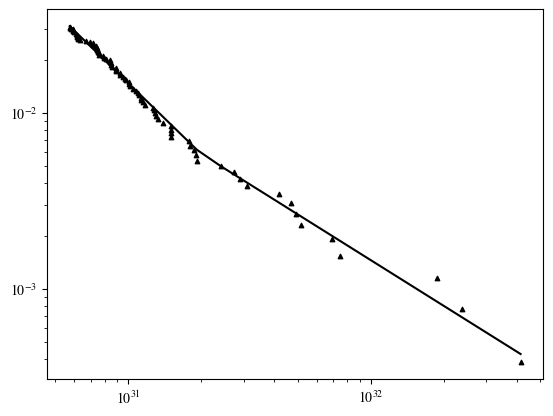

Slope below break (gamma1): -1.34 ± 0.02
Slope above break (gamma2): -0.86 ± 0.17
Number of FAST bursts which are saturated: 194
############# Fitting: FAST #############
Total input bursts for FAST : 11553 bursts
energy threshold:8.17e+27 erg/Hz and the max limit 5.00e+35 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 1.10e+30 energy units or fluence: 3.09 Jy ms
pw xmin: 1.10e+30, xmax: None
estimate using the a_star method: -0.412 -0.004
[[4.5097943253528593e+64, -2.1183231953215516], array([[ 3.60058476e+57, -5.27333295e+26],
       [-5.27333295e+26,  1.23459241e-04]])]
Bootstrapping, only using 295 points out of 328 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1679.08it/s]


boot_alpha: 0.07
############# Fitting: NRT #############
Total input bursts for NRT : 468 bursts
energy threshold:2.58e+29 erg/Hz and the max limit 5.00e+30 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 3.77e+29 energy units or fluence: 1.06 Jy ms
pw xmin: 3.77e+29, xmax: None
estimate using the a_star method: -0.591 -0.027
[[4.787459255833497e+43, -1.4534668784461269], array([[ 3.78359851e+56, -1.65737330e+26],
       [-1.65737330e+26,  2.50063152e-04]])]
Bootstrapping, only using 171 points out of 190 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2197.27it/s]


boot_alpha: 0.06
############# Fitting: HyperFlash #############
Total input bursts for HyperFlash : 127 bursts
energy threshold:8.67e+30 erg/Hz and the max limit 1.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 8.94e+30 energy units or fluence: 25.16 Jy ms
pw xmin: 8.94e+30, xmax: None
estimate using the a_star method: -0.626 -0.056
ex_max = 13
Excluding max_energy; cutting off the last 13 points
Excluded coordinates: [2.40948711e+31 2.74070274e+31 2.88285538e+31 3.09288589e+31
 4.17928738e+31 4.71164898e+31 4.89929046e+31 5.14272684e+31
 6.91430402e+31 7.48788989e+31 1.88426867e+32 2.37728954e+32
 4.15224284e+32], [0.00079759 0.00159519 0.00239278 0.00319038 0.00398797 0.00478557
 0.00558316 0.00638076 0.00717835 0.00797594 0.00877354 0.00957113
 0.01036873]
New FIT length: 32
[[5.975281463602615e+44, -1.4932258669876193], array([[1.51523214e+59, 4.07948450e+28],
       [4.07948450e+28, 1.10690585e-02]])]
Bootstrapping, only using 28 points 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 4132.86it/s]


boot_alpha: 0.05
############# Fitting: HyperFlash-2 #############
Total input bursts for HyperFlash-2 : 127 bursts
energy threshold:2.00e+31 erg/Hz and the max limit 5.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 2.41e+31 energy units or fluence: 67.80 Jy ms
pw xmin: 2.41e+31, xmax: None
estimate using the a_star method: -0.626 -0.056
[[5.416718367946511e+25, -0.8832053579121888], array([[3.22469244e+57, 4.28607050e+27],
       [4.28607050e+27, 5.80262410e-03]])]
Bootstrapping, only using 11 points out of 13 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3460.48it/s]
/tmp/ipykernel_1026525/3356683547.py:273: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


boot_alpha: 0.13


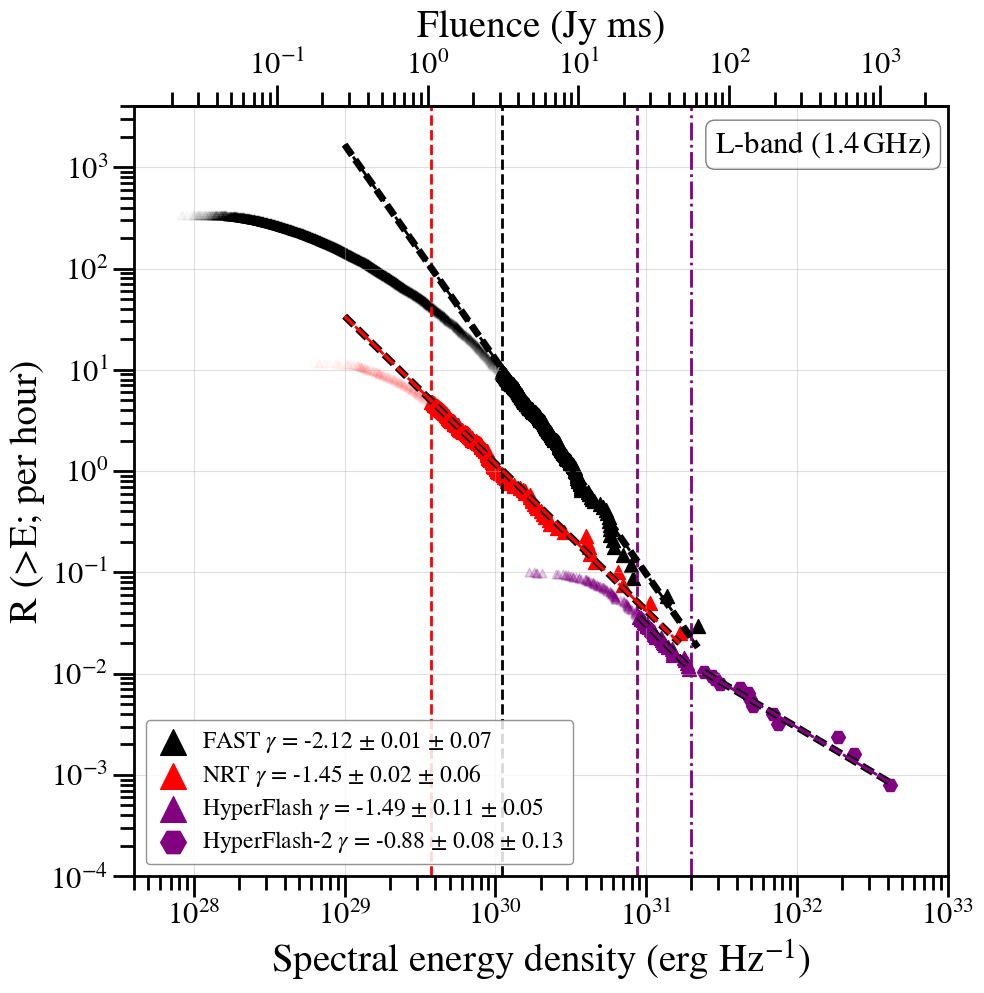

In [22]:

def cumulative_energy_dist(save_bool=False, fast_sat_toggle=False, hide_fast_sat=False):
    '''
    Function to plot the cumulative energy distribution
    mjd range: mjd_begin = 60497 mjd_end = 60570
    The observing hours are calculated using the hours_calc script.
    
    Telescopes used: FAST / NRT (Jeff Huang in prep) / HyperFlash (St/O8/Tr/Wb) - This work
    
    Output: Cumulative distribution
    '''

    energies_array_stk = isotropic_energies(fluences_stk_arr)
    energies_array_wb = isotropic_energies(fluences_wb_arr)
    energies_array_tr = isotropic_energies(fluences_tr_arr)
    energies_array_o8 = isotropic_energies(fluences_o8_arr)
    energies_array_hf = isotropic_energies(full_hyperflash_db_no_dupl_arr)
    energies_array_nc = isotropic_energies(nrt_fluence_r147)  
    energies_array_fast = isotropic_energies(fast_fluence_r147)
    
    f_limit_wb = fluence_limit(sefd=420, width=3, bw=100, snr=15)
    energie_threshold_wb = isotropic_energies(f_limit_wb)

    f_limit_tr = fluence_limit(sefd=250, width=3, bw=100, snr=15)
    energie_threshold_tr = isotropic_energies(f_limit_tr)

    f_limit_o8 = fluence_limit(sefd=310, width=3, bw=100, snr=15)
    energie_threshold_o8 = isotropic_energies(f_limit_o8)

    f_limit_stk = fluence_limit(sefd=385, width=3, bw=90, snr=15)
    energie_threshold_stk = isotropic_energies(f_limit_stk)

    f_limit_fast = 0.023 #Jyms from the Huang paper - Figure 1 caption 
    energie_threshold_fast = isotropic_energies(f_limit_fast)

    f_limit_nc = fluence_limit(sefd=35/1.4, bw=400, width=3, snr=15)
    energie_threshold_nc = isotropic_energies(f_limit_nc)

    # #Get the breakpoint
    breakpoint_hf = breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_arr, obs_h=2621.36)
    energies_hf = isotropic_energies(full_hyperflash_db_no_dupl_arr)
    energies_hf = np.sort(energies_hf)
    
    bp_idx = np.searchsorted(energies_hf, breakpoint_hf)
    
    ex_max_low = len(energies_hf) - bp_idx   # remove high-energy tail
    ex_max_high = None                       # remove nothing

    # #lists with information to loop over    
    # fluences = [fluences_wb_arr, fluences_stk_arr, fast_fluence_r117, fluences_nc_arr,fluences_nc_arr]
    # obs_hours = [185.72, 567.4, 8.67, 30.5, 30.5]
    # thresholds = [energie_threshold_wb, energie_threshold_stk, energie_threshold_fast, energie_threshold_nc, breakpoint_nc]
    # dish = ['Westerbork', "Stockert", "FAST", "Nançay", "Nançay-2"]
    # color = ['blue', 'purple', "black", "red", "red"]
    # limit = [1e35, 4e30, 2e30, breakpoint_nc, 1e31]
    
    # FAST: get sorted energies and indices of saturated bursts
    energies_fast_sorted = np.sort(energies_array_fast)
    sorted_indices_fast = np.argsort(energies_array_fast)
    saturated_mask = fast_csv['saturation_tag'].values
    saturated_indices_fast = np.where(saturated_mask[sorted_indices_fast])[0]
    print(f"Number of FAST bursts which are saturated: {len(saturated_indices_fast)}")

    #lists with information to loop over    
    # fluences = [fast_fluence_r147, nrt_fluence_r147, full_hyperflash_db_no_dupl_arr, full_hyperflash_db_no_dupl_arr, km40_fluence_r147]
    # obs_hours = [33.86, 66.87, 1141.95, 1141.95, 318]
    # thresholds = [energie_threshold_fast, energie_threshold_nc, 5.74e30, breakpoint_hf, 1.5e31]
    # dish = ["FAST", "NRT", "HyperFlash", "HyperFlash-2", "KM40"]
    # color = ["black", "red", "purple", "purple", "orange"]
    # limit = [5e35, 5e30, breakpoint_hf, 5e31, 5e31]
    # ex_max_list = [None, None, ex_max_low, None, None]
    
    #lists with information to loop over - USED IN PAPER
    fluences = [fast_fluence_r147, nrt_fluence_r147, full_hyperflash_db_no_dupl_arr, full_hyperflash_db_no_dupl_arr]
    obs_hours = [33.86, 39.70, 1253.77, 1253.77]
    thresholds = [energie_threshold_fast, energie_threshold_nc, energie_threshold_wb, breakpoint_hf]
    dish = ["FAST", "NRT", "HyperFlash", "HyperFlash-2"]
    color = ["black", "red", "purple", "purple"]
    limit = [5e35, 5e30, 1e31, 5e31]
    ex_max_list = [None, None, ex_max_low, None]
    
    #   Figure
    #plt.figure(figsize=(12,10))
    f, ax = plt.subplots(1, figsize=(10.5,10))
    
    #Dict that will be returned at the end of the function
    sols_dict = {}
    tresh = {}
    
    for fluences_arr, obs_h, energie_threshold, dish, color, limit, ex_max_num in zip(fluences, obs_hours, thresholds, dish, color, limit, ex_max_list):
            
        print(f"############# Fitting: {dish} #############")
        
        #Energy is sorted from high-low
        energies_arr = isotropic_energies(fluences_arr)
        print(f"Total input bursts for {dish} : {len(fluences_arr)} bursts")
        print(f"energy threshold:{energie_threshold:.2e} erg/Hz and the max limit {limit:.2e} erg/Hz")
        
        energies_fit, y_points_fit, energies_ex, y_points_ex, sol2, sol2_err, turning_point, b_alpha, ex_points_high = \
                power_law_fit(energies_arr, observed_time=obs_h, scale=10**18, \
                              limit=(energie_threshold, limit),limit_b=True,\
                              ex_max=ex_max_num)

        if dish in ["HyperFlash-2"]:
            marker_sym = "H"
        else:
            marker_sym = "^"
            
        # --- SPECIAL HANDLING FOR FAST ---
        if dish == "FAST":
        
            # Default: everything visible
            visible_mask = np.ones_like(energies_fit, dtype=bool)
        
            if hide_fast_sat:
                # Find which energies_fit are saturated
                # (match against original FAST energies)
                saturated_energies = energies_fast_sorted[saturated_indices_fast]
        
                # Boolean mask: True if this fit energy is saturated
                is_saturated_in_fit = np.isin(energies_fit, saturated_energies)
        
                visible_mask = ~is_saturated_in_fit
                # Total stats (true dataset)
                n_removed_total = len(saturated_indices_fast)
                n_total_all = len(energies_fast_sorted)
                
                print(f"FAST (full sample): Hiding {n_removed_total}/{n_total_all} saturated bursts ({n_removed_total/n_total_all:.2%})")
        
            plt.scatter(np.sort(energies_fit)[visible_mask],
                        np.flip(y_points_fit)[visible_mask],
                        color=color, marker="^", alpha=1.0, s=100,
                        label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
            
        else:
            plt.scatter(np.sort(energies_fit), np.flip(y_points_fit),
                        color=color, marker=marker_sym, alpha=1.0, s=100,
                        label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
    
        # plt.scatter(np.sort(energies_fit), np.flip(y_points_fit), color=color, marker = "^", alpha=1.0, s=100,\
        #              label = fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
            

        # #Get the poissonian count rate errors on the points
        # low_err = get_poisson_error(np.flip(y_points_fit)*obs_h)[0]/obs_h
        # upp_err = get_poisson_error(np.flip(y_points_fit)*obs_h)[1]/obs_h
        # plt.errorbar(np.sort(energies_fit), np.flip(y_points_fit), \
        #              yerr = (np.flip(y_points_fit)-low_err, upp_err-np.flip(y_points_fit)), \
        #              alpha = 0.8, color =color,zorder =0,capsize=0, fmt='None')
        
        if dish not in ["NRT", "FAST", "HyperFlash-2"]:
            plt.axvline(energie_threshold, color=color, linestyle='--', lw=2.0)

        if dish in ["HyperFlash-2"]:
            plt.axvline(energie_threshold, color=color, linestyle="dashdot", lw=2.0)
            
        if dish in ["NRT", "FAST"]:
            plot_range = np.logspace(np.log10(1e29), np.log10(energies_fit[-1]), 50)
            #plot_range = np.logspace(np.log10(1), np.log10(25), 50)
            energies_fit = plot_range
            alpha_plot = 0.01
            marker_size = 40
            plt.axvline(turning_point, color=color, linestyle='--', lw=2.0)

        if dish in ["HyperFlash", "HyperFlash-2", "KM40"]:
            plot_range = np.logspace(
                np.log10(energies_fit[0]),
                np.log10(energies_fit[-1]),
                50
            )
            alpha_plot = 0.10
            
        # if dish == "Westerbork" or dish == "Stockert" or dish == "Torun" or dish == "Onsala":
        #     plot_range = np.logspace(np.log10(energies_fit[0]), np.log10(energies_fit[-1]), 50)
        #     energies_fit = plot_range
        #     alpha_plot = 0.35
        #     marker_size = 60

        # Highlight FAST saturated bursts
        if dish == "FAST" and fast_sat_toggle == True:
            print(f"SATURATION CODE: Plotting the FAST burst with saturation, total is: {len(saturated_indices_fast)} bursts")
            y_vals_fast = np.arange(1, len(energies_fast_sorted)+1)[::-1] / obs_h # R(>E)
            plt.scatter(energies_fast_sorted[saturated_indices_fast], 
                        y_vals_fast[saturated_indices_fast],  # make sure this matches cumulative y
                        color="black", marker="^", s=120, edgecolor="#e6ab02", 
                        label=f"{len(saturated_indices_fast)} FAST Saturated bursts", zorder=10)
    
        #Plotting the powerlaw
        plt.plot(energies_fit,func_powerlaw(energies_fit,*sol2[0]),color=color,lw=2.0,ls='dashed')

        plt.plot(energies_fit, func_powerlaw(energies_fit, *sol2[0]), color=color, lw=2.5, \
            ls='dashed', zorder=20, path_effects=[pe.Stroke(linewidth=5, foreground='black'), pe.Normal()])
        
        #Plotting the points that were excluded from the fit (lower energies)

        plt.scatter(np.sort(energies_ex), np.flip(y_points_ex), color=color, marker="^", alpha=alpha_plot, s=marker_size)

        #To plot the largest energy values that were excluded from the plot using the ex_high function
        # if ex_max_num != None:
        #     print("Plot the high energy excluded points")
        #     alpha_plot_large = 1.0
        #     marker_size_large = 80
        #     ex_energies_high = ex_points_high[0]
        #     ex_y_points_high = ex_points_high[1]
        #     plt.scatter(np.sort(ex_energies_high), np.flip(ex_y_points_high), color=color, marker="^", \
        #                 alpha=alpha_plot_large, s=marker_size_large)

        #     #This is literally the most ugly thing I have ever done.
        #     #The circle drawn around the triangle is not centered, so I did it manually. 
        #     #This only works for a single point; god speed
        #     ex_energies_high = ex_energies_high + 2
        #     ex_y_points_high = ex_y_points_high -0.005
            
        #     # Circles around points using scatter
        #     plt.scatter(np.sort(ex_energies_high), np.flip(ex_y_points_high),
        #                 s=marker_size_large * 4, facecolors='none', edgecolors=color, linewidths=1.5)
        
        #sols_dict[color] = sol2
        #tresh[color] = energie_threshold

        #print(f"sols for fit: {sol2}")

    def fluence_to_energy(fluence):
        return isotropic_energies([fluence])[0]

    def energy_to_fluence_single(energy):
        return energy_to_fluence([energy])[0]
        
    # Secondary X-Axis
    secax = ax.secondary_xaxis('top', functions=(energy_to_fluence_single, fluence_to_energy))
    secax.set_xlabel("Fluence (Jy ms)", fontsize=28, labelpad=10)    
    secax.tick_params(axis='x', labelsize=22)

    for ax in [ax,secax]:
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)
                
            ax.tick_params(axis='y', which='major', direction='out', length=15, width=2)
            ax.tick_params(axis='y', which='minor', direction='out', length=10, width=2)
            ax.tick_params(axis='x', which='major', direction='out', length=15, width=2)
            ax.tick_params(axis='x', which='minor', direction='out', length=10, width=2)

    # Add grid to the main axis
    plt.grid(which="major", alpha=0.4)  # Grid for main axis

    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.text(0.98, 0.97, r'L-band ($1.4\,\mathrm{GHz}$)',
         transform=plt.gca().transAxes,  # current axes
         fontsize=22, verticalalignment='top', horizontalalignment='right',
         bbox=props)

    plt.ylabel("R (>E; per hour)", fontsize=28)
    plt.xlabel("Spectral energy density (erg Hz$^{-1}$)", fontsize=28)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.ylim(0.0001,4000)
    plt.xlim(4e27,1e33)

    leg = plt.legend(
    loc='lower left',
    markerscale=1.85,
    fontsize=17,
    framealpha=0.85,
    edgecolor='gray',
    fancybox=True,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.3,
    )
    
    #leg = plt.legend(loc='lower left', markerscale=2, fontsize=17)    
    for lh in leg.legendHandles: 
        lh.set_alpha(1)

    if save_bool:
        save_name = "cumulative_burst_rate_v4"
        #save_name = "cumulative_burst_rate_fast_sat_V1"
        #save_name = "cumulative_burst_rate_no_fast_sat_V1"
        plt.savefig(f"../plots/{save_name}.pdf", format = 'pdf', dpi=300, bbox_inches='tight')
        plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False, \
                    format = 'png',bbox_inches='tight', dpi=300)
    plt.show()

    return 
#cumulative_energy_dist(save_bool=False, fast_sat_toggle=True)
cumulative_energy_dist(save_bool=True, fast_sat_toggle=False, hide_fast_sat=False)

In [25]:
def nancay(csv_file, mjd_limit=False,mjd_limit_2=False):
    """
    Function to import the fluences for the NRT sample
    """
    
    nancay_df = pd.read_csv(csv_file, on_bad_lines='skip', header=0, sep=',')
    nancay_df = nancay_df.sort_values(by="MJD_at_peak")
    #display(nancay_df)
    
    mjds = nancay_df['MJD_at_peak'].values
    print(f"The first burst by NRT was detected on {np.min(mjds):.3f}")
    print(f"The last burst by NRT was detected on {np.max(mjds):.3f}")
    
    if mjd_limit ==True:
        #These dates are the entire campaign for now
        mjd_begin = 60337
        mjd_end = 60552
        nancay_df = nancay_df[nancay_df['MJD_at_peak'].between(mjd_begin, mjd_end)]
    elif mjd_limit_2 == True:
        mjd_begin = 60337
        mjd_end = 60723
        nancay_df = nancay_df[nancay_df['MJD_at_peak'].between(mjd_begin, mjd_end)]
        
    fluences = nancay_df['fluence_Jyms'].values

    #Filter on Fluences that have
    zero_fluences = fluences[fluences < 0]
    print(f"The array with Fluences below zero: {zero_fluences}")

    #Fail safe filter on Fluences -- This does nothing in the final csv file
    fluences = fluences[fluences >= 0]

    print(f"There are {len(fluences)} bursts in this sample")
    return fluences

nrt_fluence_r147_full = nancay(csv_file="../databases/NRT_burst_properties_Lband.csv",\
                                 mjd_limit_2=True)

def fluence_hyperflash_loader(csv_file, band="L", mjd_limit=False, mjd_limit_2=False, telescope=None):

    fluence_df = pd.read_csv(csv_file, index_col=0)

    fluence_df = fluence_df[["id", "toa", "fluence", "bandwidth", "central frequency", "2bit-wb-tag"]].rename(columns={"central frequency": "cent_freq"})
    fluence_df = fluence_df.dropna(subset=["toa"])

    fluence_df["burst-index"] = fluence_df['id'].str.split('-').str[0].str[1:].astype(int)
    fluence_df["telescope"] = fluence_df['id'].str.split('-').str[1].astype(str)

    ##Method to filter on telescope: wb, tr, st, o8
    if telescope is not None:
        try:
            fluence_df = fluence_df[fluence_df["telescope"] == telescope]
        except KeyError:
            print("Warning: 'telescope' column not found. Skipping filter.")

    if mjd_limit ==True:
        mjd_begin = 60337
        mjd_end = 60552
        fluence_df = fluence_df[fluence_df['toa'].between(mjd_begin, mjd_end)]
    elif mjd_limit_2 == True:
        mjd_begin = 60337
        mjd_end = 60723
        fluence_df = fluence_df[fluence_df['toa'].between(mjd_begin, mjd_end)]
        
    if band == "L":
        fluence_df = fluence_df[fluence_df["cent_freq"] > 1000]
    elif band == "P": 
        fluence_df = fluence_df[fluence_df["cent_freq"] < 1000]
        
    fluence_df = fluence_df.sort_values(by=['toa'])
    fluence_df = fluence_df.reset_index(drop=True)

    return fluence_df

full_hyperflash_db = fluence_hyperflash_loader(csv_file="../databases/FRB20240114A_HyperFlash_paper_table.csv", mjd_limit_2=True)

full_hyperflash_db_no_dupl_full = full_hyperflash_db.loc[full_hyperflash_db.groupby("burst-index")["fluence"].idxmax()]
full_hyperflash_db_no_dupl_full_arr = full_hyperflash_db_no_dupl_full['fluence'].values
print(full_hyperflash_db_no_dupl_full_arr)
full_hyperflash_db_no_dupl_full_arr[::-1].sort()

The first burst by NRT was detected on 60346.493
The last burst by NRT was detected on 60722.469
The array with Fluences below zero: [-1.73780712 -1.53612537]
There are 673 bursts in this sample
[  16.66   20.15   25.1    35.49   16.72   17.45   12.74    7.34   16.21
    8.67   15.48   42.4    11.13   11.29   14.52   11.49   15.4    22.15
   20.95   50.08   28.42   29.34   17.27   21.19   26.11   17.39   31.05
   32.37   42.07   16.15   10.33   17.17   21.13   42.42   36.76   35.93
  117.6    25.97   20.77   26.76   12.48   21.39  210.7    12.92   19.62
   25.16   14.75   23.6    16.72   12.1    30.96   28.46   37.3    31.86
   87.03   20.79   53.35  668.94   23.85  144.71  194.56   15.19    7.09
   28.53   24.11    5.78    9.16   17.37    5.25   42.19   27.55   27.39
   30.41   17.47   11.82    8.18  132.58    8.32    8.53   10.1    11.65
    9.65   32.88   16.37    4.67   13.24    5.07    9.18   15.01    8.97
   20.07   17.78   11.16   16.84    5.3    31.78   20.92  530.21   22.84
  

Calculating best minimal value for power law fit
Turning point: 5.33e+30 erg/Hz
breakpoint of the double powerlaw: 2.18e+31 erg/Hz


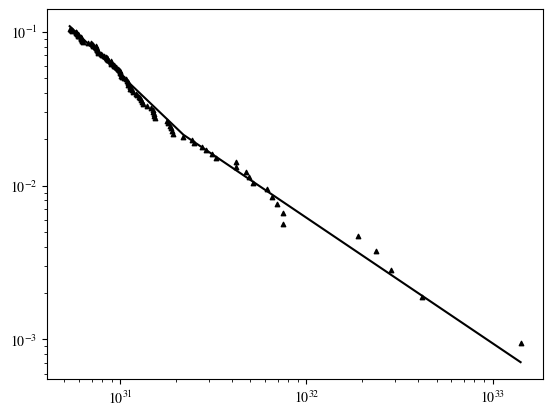

Slope below break (gamma1): -1.15 ± 0.01
Slope above break (gamma2): -0.82 ± 0.12


2.1809762700657165e+31

In [26]:
breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_full_arr, obs_h=1060.49)

Calculating best minimal value for power law fit
Turning point: 5.33e+30 erg/Hz
breakpoint of the double powerlaw: 2.18e+31 erg/Hz


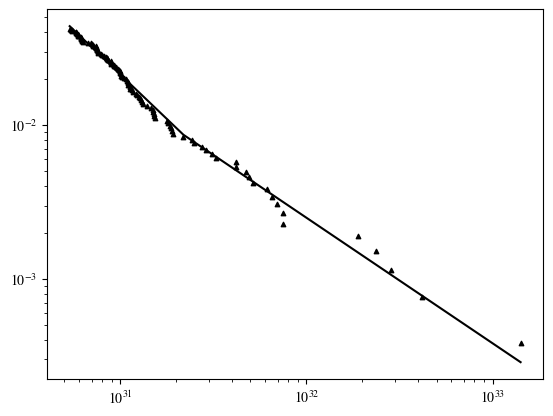

Slope below break (gamma1): -1.15 ± 0.02
Slope above break (gamma2): -0.82 ± 0.11
found breakpoint Hyperflash at: 2.18e+31 erg/Hz
############# Fitting: NRT #############
energy threshold:2.58e+29 erg/Hz and the max limit 8.00e+29 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 4.07e+29 energy units or fluence: 1.14 Jy ms
pw xmin: 4.07e+29, xmax: None
estimate using the a_star method: -0.583 -0.023
ex_max = 1
Excluding max_energy; cutting off the last 1 points
Excluded coordinates: [9.94293514e+31], [0.01786033]
New FIT length: 258
[[5.235660001162739e+43, -1.4535717387556115], array([[ 3.11349778e+56, -1.32435593e+26],
       [-1.32435593e+26,  1.95281108e-04]])]
Bootstrapping, only using 232 points out of 258 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1903.38it/s]


boot_alpha: 0.05
Plot the high energy excluded points for NRT
############# Fitting: HyperFlash #############
energy threshold:8.67e+30 erg/Hz and the max limit 1.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 8.94e+30 energy units or fluence: 25.16 Jy ms
pw xmin: 8.94e+30, xmax: None
estimate using the a_star method: -0.582 -0.047
ex_max = 21
Excluding max_energy; cutting off the last 21 points
Excluded coordinates: [2.40948711e+31 2.49655560e+31 2.74070274e+31 2.88285538e+31
 3.09288589e+31 3.27270897e+31 4.17928738e+31 4.20061027e+31
 4.71164898e+31 4.89929046e+31 5.14272684e+31 6.16338274e+31
 6.55643477e+31 6.91430402e+31 7.48788989e+31 7.50388206e+31
 1.88426867e+32 2.37728954e+32 2.86227878e+32 4.15224284e+32
 1.41543153e+33], [0.00054765 0.00109529 0.00164294 0.00219058 0.00273823 0.00328587
 0.00383352 0.00438116 0.00492881 0.00547645 0.0060241  0.00657174
 0.00711939 0.00766703 0.00821468 0.00876232 0.00930997 0.00985761
 0.01040526 

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3841.14it/s]


boot_alpha: 0.04
############# Fitting: HyperFlash-2 #############
energy threshold:2.18e+31 erg/Hz and the max limit 5.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 2.41e+31 energy units or fluence: 67.80 Jy ms
pw xmin: 2.41e+31, xmax: None
estimate using the a_star method: -0.582 -0.047
[[1.1404693302389131e+23, -0.7970117795794547], array([[7.75240130e+56, 1.67861284e+27],
       [1.67861284e+27, 3.70212880e-03]])]
Bootstrapping, only using 18 points out of 21 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3352.50it/s]
/tmp/ipykernel_1026525/3568113784.py:221: MatplotlibDeprecationWarning: The legendHandles attribute was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use legend_handles instead.
  for lh in leg.legendHandles:


boot_alpha: 0.12


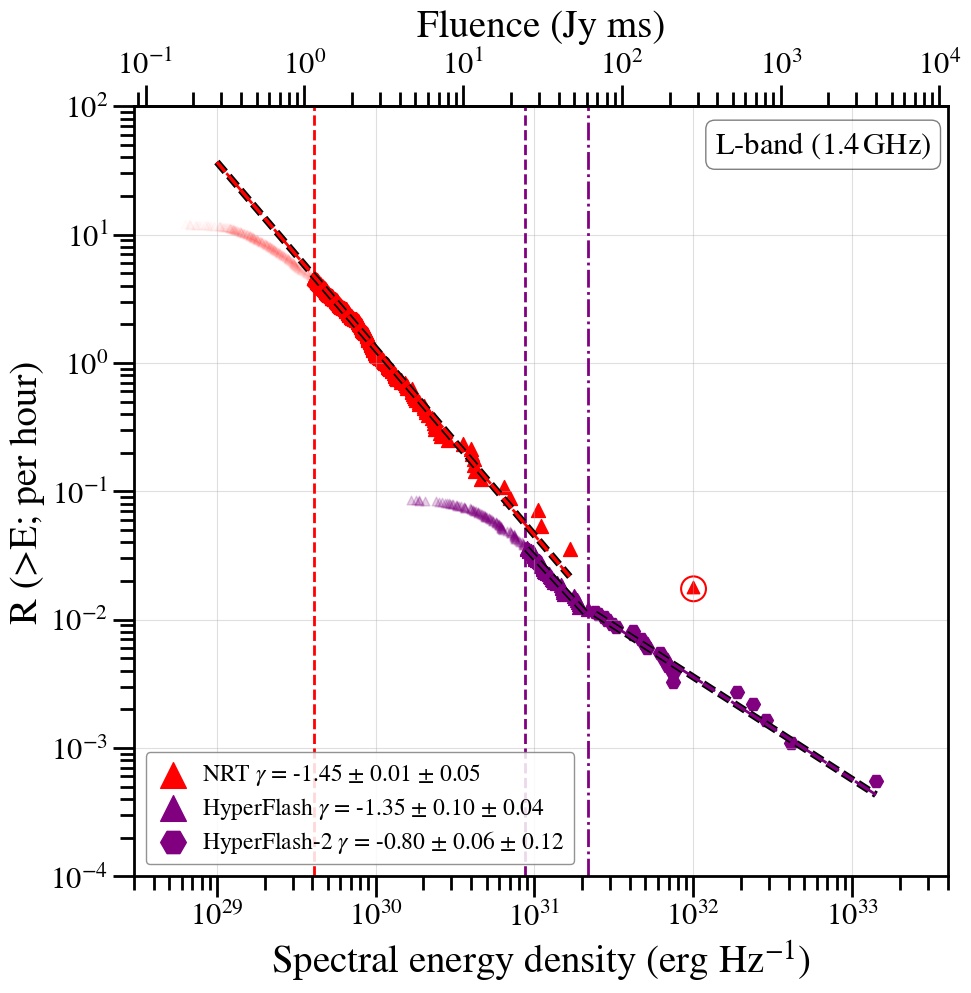

In [27]:
def cumulative_energy_dist_nrt_hf(save_bool=False, fast_sat_toggle=False, hide_fast_sat=False):
    '''
    Function to plot the cumulative energy distribution
    mjd range: mjd_begin = 60497 mjd_end = 60570
    The observing hours are calculated using the hours_calc script.
    
    Telescopes used: FAST / NRT (Jeff Huang in prep) / HyperFlash (St/O8/Tr/Wb) - This work
    
    Output: Cumulative distribution
    '''
    energies_array_hf = isotropic_energies(full_hyperflash_db_no_dupl_full_arr)
    energies_array_nc = isotropic_energies(nrt_fluence_r147_full)  
    
    f_limit_wb = fluence_limit(sefd=420, width=3, bw=100, snr=15)
    energie_threshold_wb = isotropic_energies(f_limit_wb)

    f_limit_nc = fluence_limit(sefd=35/1.4, bw=400, width=3, snr=15)
    energie_threshold_nc = isotropic_energies(f_limit_nc)

    # #Get the breakpoint
    breakpoint_hf = breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_full_arr, obs_h=2621.36)
    print(f"found breakpoint Hyperflash at: {breakpoint_hf:.2e} erg/Hz")
    energies_hf = isotropic_energies(full_hyperflash_db_no_dupl_full_arr)
    energies_hf = np.sort(energies_hf)
    
    bp_idx = np.searchsorted(energies_hf, breakpoint_hf)
    
    ex_max_low = len(energies_hf) - bp_idx   # remove high-energy tail
    ex_max_high = None                       # remove nothing

    #lists with information to loop over - USED IN PAPER
    fluences = [nrt_fluence_r147_full, full_hyperflash_db_no_dupl_full_arr, full_hyperflash_db_no_dupl_full_arr]
    obs_hours = [55.99, 1826.00, 1826.00]
    thresholds = [energie_threshold_nc, energie_threshold_wb, breakpoint_hf]
    dish = ["NRT", "HyperFlash", "HyperFlash-2"]
    color = ["red", "purple", "purple"]
    limit = [8e29, 1e31, 5e31]
    ex_max_list = [1, ex_max_low, None]
    
    #   Figure
    #plt.figure(figsize=(12,10))
    f, ax = plt.subplots(1, figsize=(10.5,10))
    
    #Dict that will be returned at the end of the function
    sols_dict = {}
    tresh = {}
    
    for fluences_arr, obs_h, energie_threshold, dish, color, limit, ex_max_num in zip(fluences, obs_hours, thresholds, dish, color, limit, ex_max_list):
            
        print(f"############# Fitting: {dish} #############")
        
        #Energy is sorted from high-low
        energies_arr = isotropic_energies(fluences_arr)

        print(f"energy threshold:{energie_threshold:.2e} erg/Hz and the max limit {limit:.2e} erg/Hz")
        
        energies_fit, y_points_fit, energies_ex, y_points_ex, sol2, sol2_err, turning_point, b_alpha, ex_points_high = \
                power_law_fit(energies_arr, observed_time=obs_h, scale=10**18, \
                              limit=(energie_threshold, limit),limit_b=True,\
                              ex_max=ex_max_num)

        if dish in ["HyperFlash-2"]:
            marker_sym = "H"
        else:
            marker_sym = "^"
            
        # --- SPECIAL HANDLING FOR FAST ---
        if dish == "FAST":
        
            # Default: everything visible
            visible_mask = np.ones_like(energies_fit, dtype=bool)
        
            if hide_fast_sat:
                # Find which energies_fit are saturated
                # (match against original FAST energies)
                saturated_energies = energies_fast_sorted[saturated_indices_fast]
        
                # Boolean mask: True if this fit energy is saturated
                is_saturated_in_fit = np.isin(energies_fit, saturated_energies)
        
                visible_mask = ~is_saturated_in_fit
                # Total stats (true dataset)
                n_removed_total = len(saturated_indices_fast)
                n_total_all = len(energies_fast_sorted)
                
                print(f"FAST (full sample): Hiding {n_removed_total}/{n_total_all} saturated bursts ({n_removed_total/n_total_all:.2%})")
        
            plt.scatter(np.sort(energies_fit)[visible_mask],
                        np.flip(y_points_fit)[visible_mask],
                        color=color, marker="^", alpha=1.0, s=100,
                        label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
            
        else:
            plt.scatter(np.sort(energies_fit), np.flip(y_points_fit),
                        color=color, marker=marker_sym, alpha=1.0, s=100,
                        label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
    
        # plt.scatter(np.sort(energies_fit), np.flip(y_points_fit), color=color, marker = "^", alpha=1.0, s=100,\
        #              label = fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
            

        # #Get the poissonian count rate errors on the points
        # low_err = get_poisson_error(np.flip(y_points_fit)*obs_h)[0]/obs_h
        # upp_err = get_poisson_error(np.flip(y_points_fit)*obs_h)[1]/obs_h
        # plt.errorbar(np.sort(energies_fit), np.flip(y_points_fit), \
        #              yerr = (np.flip(y_points_fit)-low_err, upp_err-np.flip(y_points_fit)), \
        #              alpha = 0.8, color =color,zorder =0,capsize=0, fmt='None')
        
        if dish not in ["NRT", "FAST", "HyperFlash-2"]:
            plt.axvline(energie_threshold, color=color, linestyle='--', lw=2.0)

        if dish in ["HyperFlash-2"]:
            plt.axvline(energie_threshold, color=color, linestyle="dashdot", lw=2.0)
            
        if dish in ["NRT", "FAST"]:
            plot_range = np.logspace(np.log10(1e29), np.log10(energies_fit[-1]), 50)
            #plot_range = np.logspace(np.log10(1), np.log10(25), 50)
            energies_fit = plot_range
            alpha_plot = 0.01
            marker_size = 40
            plt.axvline(turning_point, color=color, linestyle='--', lw=2.0)

        if dish in ["HyperFlash", "HyperFlash-2", "KM40"]:
            plot_range = np.logspace(
                np.log10(energies_fit[0]),
                np.log10(energies_fit[-1]),
                50
            )
            alpha_plot = 0.10
            
        #To plot the largest energy values that were excluded from the plot using the ex_high function
        if dish in ["NRT"] and ex_max_num == 1:
            print("Plot the high energy excluded points for NRT")
            alpha_plot_large = 1.0
            marker_size_large = 80
            ex_energies_high = ex_points_high[0]
            ex_y_points_high = ex_points_high[1]
            plt.scatter(np.sort(ex_energies_high), np.flip(ex_y_points_high), color=color, marker="^", \
                        alpha=alpha_plot_large, s=marker_size_large)

            #This is literally the most ugly thing I have ever done.
            #The circle drawn around the triangle is not centered, so I did it manually. 
            #This only works for a single point; god speed
            ex_energies_high = ex_energies_high + 1e30
            ex_y_points_high = ex_y_points_high - 0.0005
            
            #Circles around points using scatter
            plt.scatter(np.sort(ex_energies_high), np.flip(ex_y_points_high),
                        s=marker_size_large * 4, facecolors='none', edgecolors=color, linewidths=1.5)

        # Highlight FAST saturated bursts
        if dish == "FAST" and fast_sat_toggle == True:
            print(f"SATURATION CODE: Plotting the FAST burst with saturation, total is: {len(saturated_indices_fast)} bursts")
            y_vals_fast = np.arange(1, len(energies_fast_sorted)+1)[::-1] / obs_h # R(>E)
            plt.scatter(energies_fast_sorted[saturated_indices_fast], 
                        y_vals_fast[saturated_indices_fast],  # make sure this matches cumulative y
                        color="black", marker="^", s=120, edgecolor="#e6ab02", 
                        label=f"{len(saturated_indices_fast)} FAST Saturated bursts", zorder=10)
    
        #Plotting the powerlaw
        plt.plot(energies_fit,func_powerlaw(energies_fit,*sol2[0]),color=color,lw=2.0,ls='dashed')

        plt.plot(energies_fit, func_powerlaw(energies_fit, *sol2[0]), color=color, lw=2.5, \
            ls='dashed', zorder=20, path_effects=[pe.Stroke(linewidth=5, foreground='black'), pe.Normal()])
        
        #Plotting the points that were excluded from the fit (lower energies)
        plt.scatter(np.sort(energies_ex), np.flip(y_points_ex), color=color, marker="^", alpha=alpha_plot, s=marker_size)


    def fluence_to_energy(fluence):
        return isotropic_energies([fluence])[0]

    def energy_to_fluence_single(energy):
        return energy_to_fluence([energy])[0]
        
    # Secondary X-Axis
    secax = ax.secondary_xaxis('top', functions=(energy_to_fluence_single, fluence_to_energy))
    secax.set_xlabel("Fluence (Jy ms)", fontsize=28, labelpad=10)    
    secax.tick_params(axis='x', labelsize=22)

    for ax in [ax,secax]:
        for axis in ['top','bottom','left','right']:
            ax.spines[axis].set_linewidth(2)
                
            ax.tick_params(axis='y', which='major', direction='out', length=15, width=2)
            ax.tick_params(axis='y', which='minor', direction='out', length=10, width=2)
            ax.tick_params(axis='x', which='major', direction='out', length=15, width=2)
            ax.tick_params(axis='x', which='minor', direction='out', length=10, width=2)

    # Add grid to the main axis
    plt.grid(which="major", alpha=0.4)  # Grid for main axis

    props = dict(boxstyle='round', facecolor='white', alpha=0.5)
    plt.text(0.98, 0.97, r'L-band ($1.4\,\mathrm{GHz}$)',
         transform=plt.gca().transAxes,  # current axes
         fontsize=22, verticalalignment='top', horizontalalignment='right',
         bbox=props)

    plt.ylabel("R (>E; per hour)", fontsize=28)
    plt.xlabel("Spectral energy density (erg Hz$^{-1}$)", fontsize=28)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(fontsize=22)
    plt.yticks(fontsize=22)
    plt.ylim(0.0001,100)
    plt.xlim(3e28,4e33)

    leg = plt.legend(
    loc='lower left',
    markerscale=1.85,
    fontsize=17,
    framealpha=0.85,
    edgecolor='gray',
    fancybox=True,
    handlelength=1.5,
    handletextpad=0.5,
    labelspacing=0.3,
    )
    
    #leg = plt.legend(loc='lower left', markerscale=2, fontsize=17)    
    for lh in leg.legendHandles: 
        lh.set_alpha(1)

    if save_bool:
        save_name = "cumulative_burst_rate_nrt_hf_v1"
        #save_name = "cumulative_burst_rate_fast_sat_V1"
        #save_name = "cumulative_burst_rate_no_fast_sat_V1"
        plt.savefig(f"../plots/{save_name}.pdf", format = 'pdf', dpi=300, bbox_inches='tight')
        plt.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False, \
                    format = 'png',bbox_inches='tight', dpi=300)
    plt.show()

    return 
#cumulative_energy_dist(save_bool=False, fast_sat_toggle=True)
cumulative_energy_dist_nrt_hf(save_bool=True, fast_sat_toggle=False, hide_fast_sat=False)

Calculating best minimal value for power law fit
Turning point: 5.74e+30 erg/Hz
breakpoint of the double powerlaw: 2.00e+31 erg/Hz


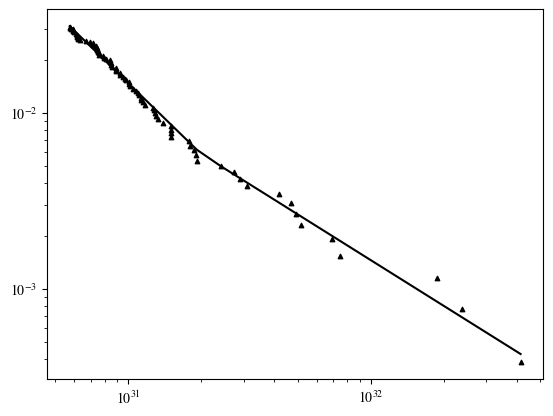

Slope below break (gamma1): -1.34 ± 0.02
Slope above break (gamma2): -0.86 ± 0.17
Calculating best minimal value for power law fit
Turning point: 5.33e+30 erg/Hz
breakpoint of the double powerlaw: 2.18e+31 erg/Hz


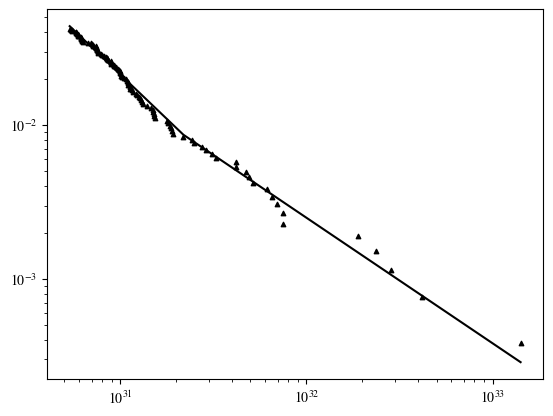

Slope below break (gamma1): -1.15 ± 0.02
Slope above break (gamma2): -0.82 ± 0.11
Breakpoint HyperFlash (full): 2.18e+31 erg/Hz
Saturated FAST bursts: 194
############# Fitting: FAST #############
Total input bursts for FAST : 11553 bursts
energy threshold:8.17e+27 erg/Hz and the max limit 5.00e+35 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 1.10e+30 energy units or fluence: 3.09 Jy ms
pw xmin: 1.10e+30, xmax: None
estimate using the a_star method: -0.412 -0.004
[[4.5097943253528593e+64, -2.1183231953215516], array([[ 3.60058476e+57, -5.27333295e+26],
       [-5.27333295e+26,  1.23459241e-04]])]
Bootstrapping, only using 295 points out of 328 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1757.32it/s]


boot_alpha: 0.07
############# Fitting: NRT #############
Total input bursts for NRT : 468 bursts
energy threshold:2.58e+29 erg/Hz and the max limit 5.00e+30 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 3.77e+29 energy units or fluence: 1.06 Jy ms
pw xmin: 3.77e+29, xmax: None
estimate using the a_star method: -0.591 -0.027
[[4.787459255833497e+43, -1.4534668784461269], array([[ 3.78359851e+56, -1.65737330e+26],
       [-1.65737330e+26,  2.50063152e-04]])]
Bootstrapping, only using 171 points out of 190 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2282.96it/s]


boot_alpha: 0.06
############# Fitting: HyperFlash #############
Total input bursts for HyperFlash : 127 bursts
energy threshold:8.67e+30 erg/Hz and the max limit 1.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 8.94e+30 energy units or fluence: 25.16 Jy ms
pw xmin: 8.94e+30, xmax: None
estimate using the a_star method: -0.626 -0.056
ex_max = 13
Excluding max_energy; cutting off the last 13 points
Excluded coordinates: [2.40948711e+31 2.74070274e+31 2.88285538e+31 3.09288589e+31
 4.17928738e+31 4.71164898e+31 4.89929046e+31 5.14272684e+31
 6.91430402e+31 7.48788989e+31 1.88426867e+32 2.37728954e+32
 4.15224284e+32], [0.00079759 0.00159519 0.00239278 0.00319038 0.00398797 0.00478557
 0.00558316 0.00638076 0.00717835 0.00797594 0.00877354 0.00957113
 0.01036873]
New FIT length: 32
[[5.975281463602615e+44, -1.4932258669876193], array([[1.51523214e+59, 4.07948450e+28],
       [4.07948450e+28, 1.10690585e-02]])]
Bootstrapping, only using 28 points 

...

boot_alpha: 0.05
Plot the high energy excluded points for NRT
############# Fitting: HyperFlash #############
Total input bursts for HyperFlash : 157 bursts
energy threshold:8.67e+30 erg/Hz and the max limit 1.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 8.94e+30 energy units or fluence: 25.16 Jy ms
pw xmin: 8.94e+30, xmax: None
estimate using the a_star method: -0.582 -0.047
ex_max = 21
Excluding max_energy; cutting off the last 21 points
Excluded coordinates: [2.40948711e+31 2.49655560e+31 2.74070274e+31 2.88285538e+31
 3.09288589e+31 3.27270897e+31 4.17928738e+31 4.20061027e+31
 4.71164898e+31 4.89929046e+31 5.14272684e+31 6.16338274e+31
 6.55643477e+31 6.91430402e+31 7.48788989e+31 7.50388206e+31
 1.88426867e+32 2.37728954e+32 2.86227878e+32 4.15224284e+32
 1.41543153e+33], [0.00054765 0.00109529 0.00164294 0.00219058 0.00273823 0.00328587
 0.00383352 0.00438116 0.00492881 0.00547645 0.0060241  0.00657174
 0.00711939 0.00766703 0.0082146

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3443.46it/s]


boot_alpha: 0.04
############# Fitting: HyperFlash-2 #############
Total input bursts for HyperFlash-2 : 157 bursts
energy threshold:2.18e+31 erg/Hz and the max limit 5.00e+31 erg/Hz
Calculating best minimal value for power law fit
No limit_b, Turning point: 2.41e+31 energy units or fluence: 67.80 Jy ms
pw xmin: 2.41e+31, xmax: None
estimate using the a_star method: -0.582 -0.047
[[1.1404693302389131e+23, -0.7970117795794547], array([[7.75240130e+56, 1.67861284e+27],
       [1.67861284e+27, 3.70212880e-03]])]
Bootstrapping, only using 18 points out of 21 points


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2816.97it/s]


boot_alpha: 0.11


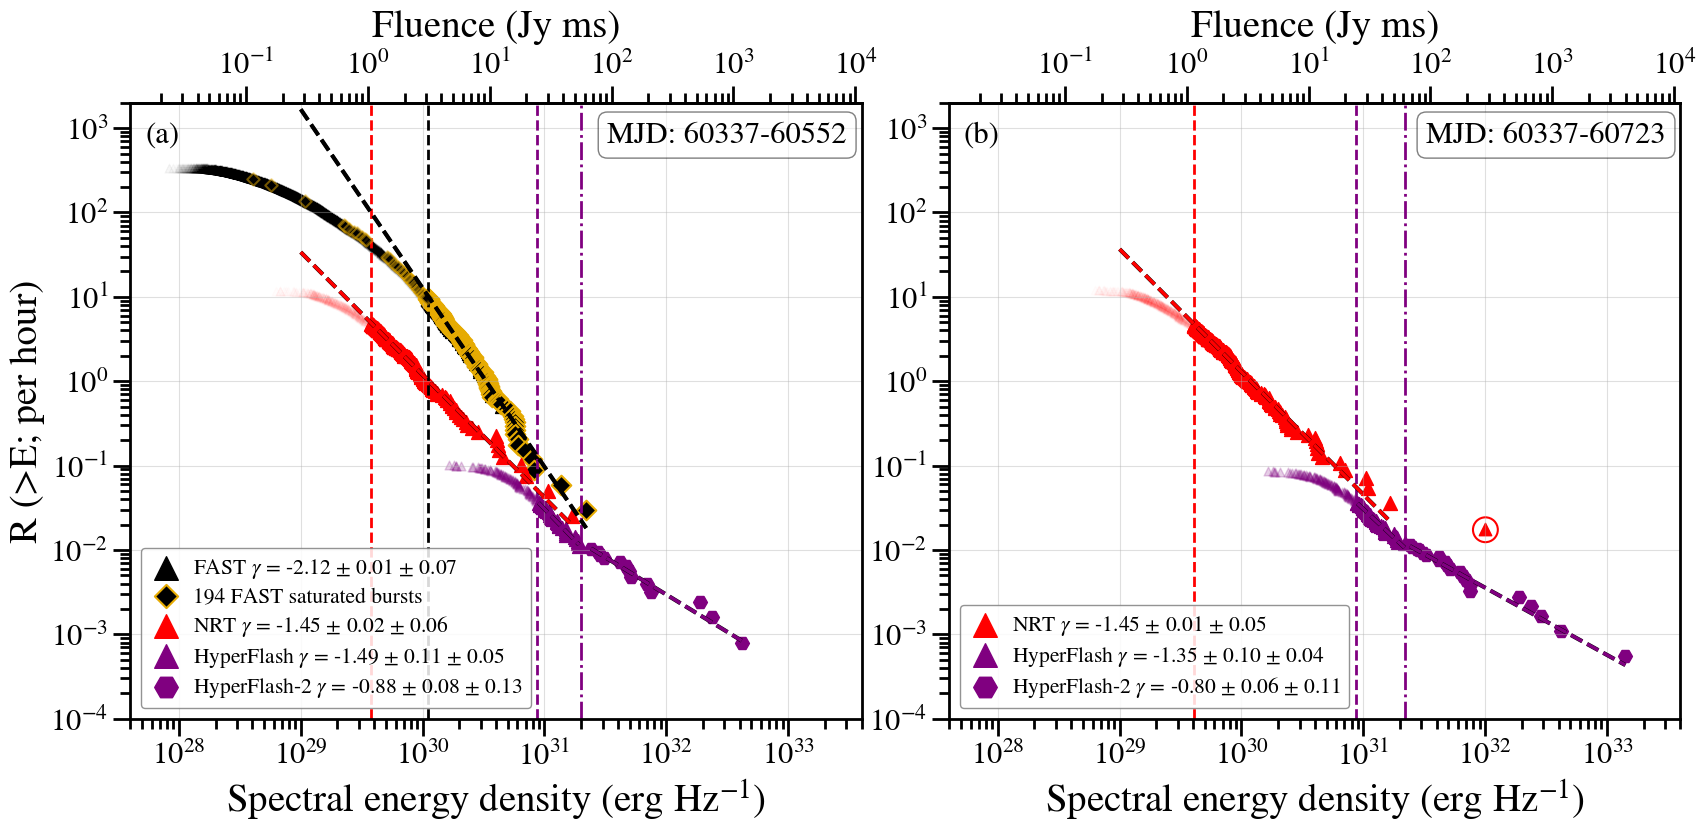

In [29]:
def _plot_panel(ax, fluences_list, obs_hours_list, thresholds_list, dish_list,
                color_list, limit_list, ex_max_list,
                fast_sat_toggle, hide_fast_sat,
                energies_fast_sorted=None, saturated_indices_fast=None):
    """
    Shared inner loop for cumulative energy distribution panels.
    Draws onto the provided `ax`.
    """

    alpha_plot = 0.1
    marker_size = 60

    for fluences_arr, obs_h, energie_threshold, dish, color, limit, ex_max_num in zip(
            fluences_list, obs_hours_list, thresholds_list,
            dish_list, color_list, limit_list, ex_max_list):

        print(f"############# Fitting: {dish} #############")
        print(f"Total input bursts for {dish} : {len(fluences_arr)} bursts")
        energies_arr = isotropic_energies(fluences_arr)
        print(f"energy threshold:{energie_threshold:.2e} erg/Hz and the max limit {limit:.2e} erg/Hz")

        energies_fit, y_points_fit, energies_ex, y_points_ex, sol2, sol2_err, turning_point, b_alpha, ex_points_high = \
            power_law_fit(energies_arr, observed_time=obs_h, scale=10**18,
                          limit=(energie_threshold, limit), limit_b=True,
                          ex_max=ex_max_num)

        marker_sym = "H" if dish == "HyperFlash-2" else "^"

        # =========================
        # FAST HANDLING
        # =========================
        if dish == "FAST":

            visible_mask = np.ones_like(energies_fit, dtype=bool)
            if hide_fast_sat and saturated_indices_fast is not None:
                saturated_energies = energies_fast_sorted[saturated_indices_fast]
                is_saturated_in_fit = np.isin(energies_fit, saturated_energies)
                visible_mask = ~is_saturated_in_fit
                print(f"FAST: hiding {len(saturated_indices_fast)}/{len(energies_fast_sorted)} saturated bursts")

            if fast_sat_toggle and saturated_indices_fast is not None:

                y_vals_fast = np.arange(1, len(energies_fast_sorted) + 1)[::-1] / obs_h

                is_sat = np.zeros_like(energies_fast_sorted, dtype=bool)
                is_sat[saturated_indices_fast] = True

                is_above = energies_fast_sorted >= turning_point  # was energie_threshold
                #is_above = energies_fast_sorted >= energie_threshold

                clean_above = ~is_sat &  is_above
                clean_below = ~is_sat & ~is_above
                sat_above   =  is_sat &  is_above
                sat_below   =  is_sat & ~is_above

                # Clean above threshold — full size/opacity
                ax.scatter(energies_fast_sorted[clean_above], y_vals_fast[clean_above],
                           color=color, marker="^", alpha=1.0, s=100,
                           label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")

                # Clean below threshold — small & faint
                ax.scatter(energies_fast_sorted[clean_below], y_vals_fast[clean_below],
                           color=color, marker="^", alpha=0.01, s=40)

                # Saturated above threshold — full size gold outline
                ax.scatter(energies_fast_sorted[sat_above], y_vals_fast[sat_above],
                           facecolors='black', edgecolors="#e6ab02", marker="D",
                           alpha=1.0, s=100, linewidths=1.5,
                           label=f"{len(saturated_indices_fast)} FAST saturated bursts")

                # Saturated below threshold — small & faint gold outline
                ax.scatter(energies_fast_sorted[sat_below], y_vals_fast[sat_below],
                           facecolors='black', edgecolors="#e6ab02", marker="D",
                           alpha=0.5, s=40, linewidths=1.5, zorder=10)

            else:
                # No toggle — standard behaviour
                ax.scatter(np.sort(energies_fit)[visible_mask],
                           np.flip(y_points_fit)[visible_mask],
                           color=color, marker="^", alpha=1.0, s=100,
                           label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")

        # =========================
        # NON-FAST CASES
        # =========================
        else:
            ax.scatter(np.sort(energies_fit), np.flip(y_points_fit),
                       color=color, marker=marker_sym, alpha=1.0, s=100,
                       label=fr"{dish} $\gamma$ = {sol2[0][1]:.2f} $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")

        # =========================
        # THRESHOLDS
        # =========================
        if dish not in ["NRT", "FAST", "HyperFlash-2"]:
            ax.axvline(energie_threshold, color=color, linestyle='--', lw=2.0)
        if dish == "HyperFlash-2":
            ax.axvline(energie_threshold, color=color, linestyle="dashdot", lw=2.0)

        # =========================
        # PLOT RANGE ADJUSTMENTS
        # =========================
        if dish in ["NRT", "FAST"]:
            plot_range = np.logspace(np.log10(1e29), np.log10(energies_fit[-1]), 50)
            energies_fit = plot_range
            alpha_plot = 0.01
            marker_size = 40
            ax.axvline(turning_point, color=color, linestyle='--', lw=2.0)

        if dish in ["HyperFlash", "HyperFlash-2", "KM40"]:
            plot_range = np.logspace(np.log10(energies_fit[0]), np.log10(energies_fit[-1]), 50)
            alpha_plot = 0.10

        # =========================
        # NRT EXCLUDED HIGH-ENERGY POINT
        # =========================
        if dish == "NRT" and ex_max_num == 1:
            print("Plot the high energy excluded points for NRT")
            ex_energies_high = ex_points_high[0]
            ex_y_points_high = ex_points_high[1]
            ax.scatter(np.sort(ex_energies_high), np.flip(ex_y_points_high),
                       color=color, marker="^", alpha=1.0, s=80)
            ax.scatter(np.sort(ex_energies_high) + 1e30, np.flip(ex_y_points_high) - 0.0005,
                       s=80 * 4, facecolors='none', edgecolors=color, linewidths=1.5)

        # =========================
        # POWER LAW FIT
        # =========================
        ax.plot(energies_fit, func_powerlaw(energies_fit, *sol2[0]),
                color=color, lw=2.5, ls='dashed', zorder=20,
                path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])

        # =========================
        # EXCLUDED LOW-ENERGY POINTS
        # =========================
        if not (dish == "FAST" and fast_sat_toggle):
            ax.scatter(np.sort(energies_ex), np.flip(y_points_ex),
                       color=color, marker="^", alpha=alpha_plot, s=marker_size)
        
def cumulative_energy_dist_combined(save_bool=False, fast_sat_toggle=False, hide_fast_sat=False):
    """
    Side-by-side cumulative energy distribution:
      Left panel  — FAST + NRT + HyperFlash (standard sample)
      Right panel — NRT + HyperFlash        (full sample)
    """

    # ── Shared thresholds ──────────────────────────────────────────────────
    f_limit_wb  = fluence_limit(sefd=420,    width=3, bw=100, snr=15)
    f_limit_nc  = fluence_limit(sefd=35/1.4, width=3, bw=400, snr=15)
    energie_threshold_wb = isotropic_energies(f_limit_wb)
    energie_threshold_nc = isotropic_energies(f_limit_nc)

    f_limit_fast         = 0.023
    energie_threshold_fast = isotropic_energies(f_limit_fast)

    # ── Panel 1 breakpoint (standard HyperFlash array) ────────────────────
    breakpoint_hf = breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_arr, obs_h=2621.36)
    energies_hf   = np.sort(isotropic_energies(full_hyperflash_db_no_dupl_arr))
    bp_idx        = np.searchsorted(energies_hf, breakpoint_hf)
    ex_max_low    = len(energies_hf) - bp_idx

    # ── Panel 2 breakpoint (full HyperFlash array) ────────────────────────
    breakpoint_hf_full = breakpoint_calculator(fluences=full_hyperflash_db_no_dupl_full_arr, obs_h=2621.36)
    print(f"Breakpoint HyperFlash (full): {breakpoint_hf_full:.2e} erg/Hz")
    energies_hf_full = np.sort(isotropic_energies(full_hyperflash_db_no_dupl_full_arr))
    bp_idx_full      = np.searchsorted(energies_hf_full, breakpoint_hf_full)
    ex_max_low_full  = len(energies_hf_full) - bp_idx_full

    # ── FAST saturation bookkeeping (panel 1 only) ────────────────────────
    energies_array_fast   = isotropic_energies(fast_fluence_r147)
    energies_fast_sorted  = np.sort(energies_array_fast)
    sorted_indices_fast   = np.argsort(energies_array_fast)
    saturated_mask        = fast_csv['saturation_tag'].values
    saturated_indices_fast = np.where(saturated_mask[sorted_indices_fast])[0]
    print(f"Saturated FAST bursts: {len(saturated_indices_fast)}")

    # ── Panel configs ──────────────────────────────────────────────────────
    panel1 = dict(
        fluences_list   = [fast_fluence_r147, nrt_fluence_r147,
                           full_hyperflash_db_no_dupl_arr, full_hyperflash_db_no_dupl_arr],
        obs_hours_list  = [33.86, 39.70, 1253.77, 1253.77],
        thresholds_list = [energie_threshold_fast, energie_threshold_nc,
                           energie_threshold_wb, breakpoint_hf],
        dish_list       = ["FAST", "NRT", "HyperFlash", "HyperFlash-2"],
        color_list      = ["black", "red", "purple", "purple"],
        limit_list      = [5e35, 5e30, 1e31, 5e31],
        ex_max_list     = [None, None, ex_max_low, None],
        ylim            = (0.0001, 2000),
        xlim            = (4e27,4e33),
        label_text = r'MJD: 60337-60552',
        #label_text = r'L-band ($1.4\,\mathrm{GHz}$)' + '\nMJD: 60337-60552',
    )

    panel2 = dict(
        fluences_list   = [nrt_fluence_r147_full,
                           full_hyperflash_db_no_dupl_full_arr,
                           full_hyperflash_db_no_dupl_full_arr],
        obs_hours_list  = [55.99, 1826.00, 1826.00],
        thresholds_list = [energie_threshold_nc, energie_threshold_wb, breakpoint_hf_full],
        dish_list       = ["NRT", "HyperFlash", "HyperFlash-2"],
        color_list      = ["red", "purple", "purple"],
        limit_list      = [8e29, 1e31, 5e31],
        ex_max_list     = [1, ex_max_low_full, None],
        ylim            = (0.0001, 2000),
        xlim            = (4e27, 4e33),
        label_text = r'MJD: 60337-60723',
        #label_text = r'L-band ($1.4\,\mathrm{GHz}$)' + '\nMJD: 60337-60723',
    )

    # ── Figure ─────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    plt.subplots_adjust(wspace=0.12)   # tighten gap; tweak to taste

    def fluence_to_energy(fluence):
        return isotropic_energies([fluence])[0]
    def energy_to_fluence_single(energy):
        return energy_to_fluence([energy])[0]

    for ax, panel, fast_kwargs in [
        (ax1, panel1, dict(energies_fast_sorted=energies_fast_sorted,
                           saturated_indices_fast=saturated_indices_fast)),
        (ax2, panel2, dict(energies_fast_sorted=None,
                           saturated_indices_fast=None)),
    ]:
        _plot_panel(ax,
                    panel['fluences_list'], panel['obs_hours_list'],
                    panel['thresholds_list'], panel['dish_list'],
                    panel['color_list'], panel['limit_list'], panel['ex_max_list'],
                    fast_sat_toggle=fast_sat_toggle,
                    hide_fast_sat=hide_fast_sat,
                    **fast_kwargs)

        # Secondary x-axis
        secax = ax.secondary_xaxis('top', functions=(energy_to_fluence_single, fluence_to_energy))
        secax.set_xlabel("Fluence (Jy ms)", fontsize=28, labelpad=10)
        secax.tick_params(axis='x', labelsize=22)

        # Spine / tick styling
        for a in [ax, secax]:
            for spine in a.spines.values():
                spine.set_linewidth(2)
            a.tick_params(axis='y', which='major', direction='out', length=12.5, width=2)
            a.tick_params(axis='y', which='minor', direction='out', length=7.5, width=2)
            a.tick_params(axis='x', which='major', direction='out', length=12.5, width=2)
            a.tick_params(axis='x', which='minor', direction='out', length=7.5, width=2)

        ax.grid(which="major", alpha=0.4)
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlim(*panel['xlim'])
        ax.set_ylim(*panel['ylim'])
        ax.tick_params(axis='both', labelsize=22)

        # Band label box
        props = dict(boxstyle='round', facecolor='white', alpha=0.5)
        ax.text(0.98, 0.97, panel['label_text'],
                transform=ax.transAxes, fontsize=22,
                verticalalignment='top', horizontalalignment='right', bbox=props, multialignment='center')

        ax.set_xlabel("Spectral energy density (erg Hz$^{-1}$)", fontsize=28)

        leg = ax.legend(loc='lower left', markerscale=1.7, fontsize=15.5,
                        framealpha=0.85, edgecolor='gray', fancybox=True,
                        handlelength=1.5, handletextpad=0.5, labelspacing=0.3)
        for lh, text in zip(leg.legend_handles, leg.get_texts()):
            lh.set_alpha(1)
            if "saturated" in text.get_text():
                lh.set_sizes([140])

    # Only left panel gets a y-label; right panel shares the scale
    ax1.set_ylabel("R (>E; per hour)", fontsize=28)
    #ax2.set_yticklabels([])   # remove duplicate y-tick labels on right panel

    # Panel labels
    ax1.text(0.02, 0.97, "(a)", transform=ax1.transAxes, fontsize=22, va='top')
    ax2.text(0.02, 0.97, "(b)", transform=ax2.transAxes, fontsize=22, va='top')

    if save_bool:
        save_name = "cumulative_burst_rate_combined_v4"
        fig.savefig(f"../plots/{save_name}.pdf", format='pdf', dpi=300, bbox_inches='tight')
        fig.savefig(f"../plots/{save_name}.png", facecolor='white', transparent=False,
                    format='png', bbox_inches='tight', dpi=300)

    plt.show()

cumulative_energy_dist_combined(save_bool=True, fast_sat_toggle=True, hide_fast_sat=False)

Calculating best minimal value for power law fit
Turning point: 5.33e+30 erg/Hz
breakpoint of the double powerlaw: 2.18e+31 erg/Hz


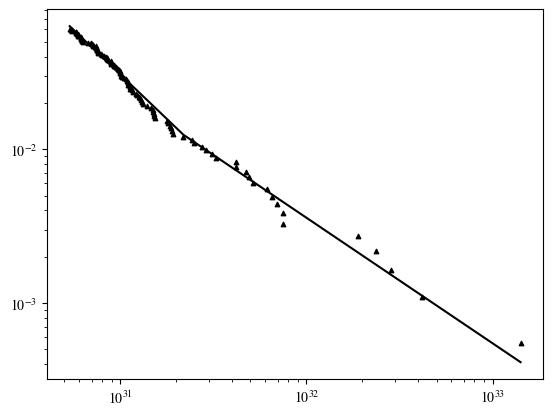

Slope below break (gamma1): -1.15 ± 0.01
Slope above break (gamma2): -0.82 ± 0.12
Completeness threshold : 8.671e+30 erg/Hz
Breakpoint             : 2.181e+31 erg/Hz
Total bursts           : 157  |  above breakpoint: 21
############# Fitting: HyperFlash-1 #############
threshold=8.671e+30  limit=1.000e+31  ex_max=21
Calculating best minimal value for power law fit
No limit_b, Turning point: 8.94e+30 energy units or fluence: 25.16 Jy ms
pw xmin: 8.94e+30, xmax: None
estimate using the a_star method: -0.582 -0.047
ex_max = 21
Excluding max_energy; cutting off the last 21 points
Excluded coordinates: [2.40948711e+31 2.49655560e+31 2.74070274e+31 2.88285538e+31
 3.09288589e+31 3.27270897e+31 4.17928738e+31 4.20061027e+31
 4.71164898e+31 4.89929046e+31 5.14272684e+31 6.16338274e+31
 6.55643477e+31 6.91430402e+31 7.48788989e+31 7.50388206e+31
 1.88426867e+32 2.37728954e+32 2.86227878e+32 4.15224284e+32
 1.41543153e+33], [0.00054765 0.00109529 0.00164294 0.00219058 0.00273823 0.00328587
 0.00

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 3811.72it/s]


boot_alpha: 0.04
############# Fitting: HyperFlash-2 #############
threshold=2.181e+31  limit=5.000e+31  ex_max=None
Calculating best minimal value for power law fit
No limit_b, Turning point: 2.41e+31 energy units or fluence: 67.80 Jy ms
pw xmin: 2.41e+31, xmax: None
estimate using the a_star method: -0.582 -0.047
[[1.1404693302389131e+23, -0.7970117795794547], array([[7.75240130e+56, 1.67861284e+27],
       [1.67861284e+27, 3.70212880e-03]])]
Bootstrapping, only using 18 points out of 21 points


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 2722.48it/s]


boot_alpha: 0.12


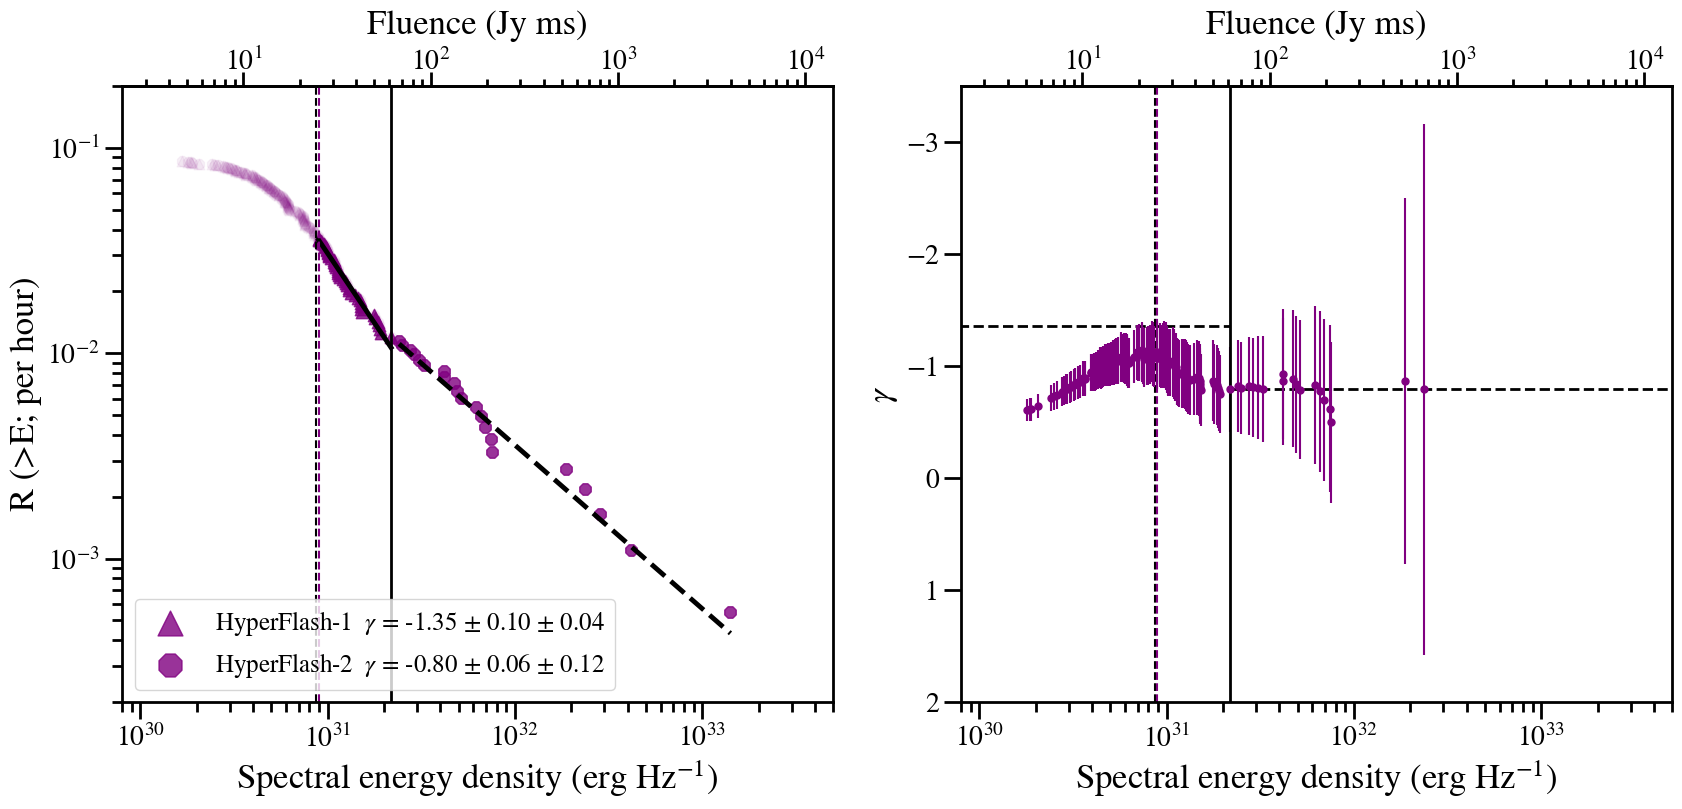

In [33]:
def distr_hyperflash_broken(fluences, telescope, mjd_toggle=True):
    """
    Two panel analysis of the hyperflash burst distribution with a broken powerlaw.
    Left panel:  Cumulative rate distribution with broken powerlaw fit (two segments).
                 Tail exclusion is handled via ex_max passed to power_law_fit.
    Right panel: Sliding gamma plot using gamma_slopes().
    Both panels have a secondary x-axis showing fluence <-> energy conversion.
    """

    telescopes = {
        "HyperFlash": dict(sefd=420, bw=100, width=3, color="purple",    lowerlimit=30),
    }
    tel        = telescopes[telescope]
    color_dish = tel["color"]

    # ── Thresholds & observation time ───────────────────────────────────────
    f_limit           = fluence_limit(sefd=tel["sefd"], width=tel["width"], bw=tel["bw"], snr=15)
    energie_threshold = isotropic_energies([f_limit])[0]

    obs_h     = 1826.00
    save_name = "hyperflash_alpha"

    # ── Convert fluences → energies, then find breakpoint ──────────────────
    energies_arr   = isotropic_energies(fluences)
    energies_sorted = np.sort(energies_arr)

    breakpoint_val = breakpoint_calculator(fluences=fluences, obs_h=obs_h)
    bp_idx         = np.searchsorted(energies_sorted, breakpoint_val)
    ex_max_low     = len(energies_sorted) - bp_idx   # exclude everything above breakpoint for seg-1

    print(f"Completeness threshold : {energie_threshold:.3e} erg/Hz")
    print(f"Breakpoint             : {breakpoint_val:.3e} erg/Hz")
    print(f"Total bursts           : {len(energies_sorted)}  |  above breakpoint: {len(energies_sorted) - bp_idx}")

    # ── Secondary axis helpers ──────────────────────────────────────────────
    def energy_to_fluence_ax(energy):
        return energy_to_fluence([energy])[0]

    def fluence_to_energy_ax(fluence):
        return isotropic_energies([fluence])[0]

    # ── Figure layout ───────────────────────────────────────────────────────
    fig = plt.figure(figsize=(20, 8))
    gs  = gridspec.GridSpec(ncols=2, nrows=1,
                            width_ratios=[1, 1], height_ratios=[1],
                            wspace=0.18, hspace=0.12)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])

    # ════════════════════════════════════════════════════════════════════════
    # LEFT PANEL — broken powerlaw, two segments
    # Segment 1: fit below breakpoint, ex_max excludes the high-E tail
    # Segment 2: fit above breakpoint, no exclusion needed
    # ════════════════════════════════════════════════════════════════════════
    seg_configs = [
        dict(
            name      = f"{telescope}-1",
            threshold = energie_threshold,
            limit     = 1e31,         # upper limit is the breakpoint
            ex_max    = ex_max_low,             # excludes high-E tail via power_law_fit
            marker    = "^",
            ls        = "-",
        ),
        dict(
            name      = f"{telescope}-2",
            threshold = breakpoint_val,         # lower limit is the breakpoint
            limit     = 5e31,
            ex_max    = None,                   # no tail exclusion for high-E segment
            marker    = "8",
            ls        = "--",
        ),
    ]

    for cfg in seg_configs:
        print(f"############# Fitting: {cfg['name']} #############")
        print(f"threshold={cfg['threshold']:.3e}  limit={cfg['limit']:.3e}  ex_max={cfg['ex_max']}")

        energies_fit, y_points_fit, energies_ex, y_points_ex, \
            sol2, sol2_err, turning_point, b_alpha, ex_points_high = \
            power_law_fit(energies_arr, observed_time=obs_h, scale=10**18,
                          limit=(cfg['threshold'], cfg['limit']),
                          limit_b=True, ex_max=cfg['ex_max'])

        energies_fit = np.sort(energies_fit)
        y_points_fit = np.flip(y_points_fit)

        ax1.scatter(energies_fit, y_points_fit,
                    color=color_dish, marker=cfg['marker'], alpha=0.8, s=80,
                    label=fr"{cfg['name']}  $\gamma$ = {sol2[0][1]:.2f}"
                          fr" $\pm$ {sol2_err[1]:.2f} $\pm$ {b_alpha:.2f}")
        ax1.scatter(np.sort(energies_ex), np.flip(y_points_ex),
                    color=color_dish, marker=cfg['marker'], alpha=0.05, s=60)

        plot_range = np.logspace(np.log10(energies_fit[0]), np.log10(energies_fit[-1]), 200)
        ax1.plot(plot_range, func_powerlaw(plot_range, *sol2[0]),
                 color="black", linestyle=cfg['ls'], lw=3.5)

        # Reference lines
        if cfg['name'] == f"{telescope}-1":
            ax1.axvline(float(energie_threshold), color="black", linestyle="--", lw=1.5)
            ax2.axvline(float(energie_threshold), color="black", linestyle="--", lw=1.5)
            ax1.axvline(turning_point, color=color_dish, linestyle="--", lw=1.5)
            ax2.axvline(turning_point, color=color_dish, linestyle="--", lw=1.5)
            ax2.hlines(sol2[0][1], xmin=1e28, xmax=breakpoint_val,
                       lw=2.0, ls="--", color="black")
        else:
            ax2.hlines(sol2[0][1], xmin=breakpoint_val, xmax=1e34,
                       lw=2.0, ls="--", color="black")

    ax1.axvline(breakpoint_val, color="black", linestyle="solid", lw=2)
    ax1.legend(loc="lower left", markerscale=2, fontsize=18)
    ax1.set_ylim(0.0002, 0.2)
    ax1.set_ylabel("R (>E; per hour)", fontsize=25)

    # ════════════════════════════════════════════════════════════════════════
    # RIGHT PANEL — sliding gamma
    # ════════════════════════════════════════════════════════════════════════
    total_gamma, energy_threshold_g, error_ar = gamma_slopes(energies_arr, conf_level=2)

    ax2.errorbar(energy_threshold_g[:-2], total_gamma[:-2],
                 yerr=np.abs(error_ar),
                 fmt=".", color=color_dish, markersize=10)
    ax2.axvline(breakpoint_val, color="black", linestyle="solid", lw=2)
    ax2.set_ylabel(r"$\gamma$", fontsize=25)
    ax2.set_ylim(2, -3.5)
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(1.0))

    # ── Shared limits and labels ────────────────────────────────────────────
    ax1.set_xlim(8e29, 5e33)
    ax2.set_xlim(8e29, 5e33)
    ax1.set_xlabel("Spectral energy density (erg Hz$^{-1}$)", fontsize=25)
    ax2.set_xlabel("Spectral energy density (erg Hz$^{-1}$)", fontsize=25)

    # ── Secondary x-axes ────────────────────────────────────────────────────
    for ax in [ax1, ax2]:
        secax = ax.secondary_xaxis("top", functions=(energy_to_fluence_ax, fluence_to_energy_ax))
        secax.set_xlabel("Fluence (Jy ms)", fontsize=25, labelpad=10)
        secax.tick_params(axis="x", labelsize=20, pad=-2.5)
        for spine in secax.spines.values():
            spine.set_linewidth(2)
        secax.tick_params(axis="x", which="major", direction="out", length=10, width=2)
        secax.tick_params(axis="x", which="minor", direction="out", length=5,  width=2)

    # ── Spine and tick styling ───────────────────────────────────────────────
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        ax.tick_params(axis="y", which="major", direction="out", length=12.5, width=2)
        ax.tick_params(axis="y", which="minor", direction="out", length=7.5,  width=2)
        ax.tick_params(axis="x", which="major", direction="out", length=12.5, width=2)
        ax.tick_params(axis="x", which="minor", direction="out", length=7.5,  width=2)
        ax.set_xscale("log")
        ax.tick_params(axis="both", which="major", labelsize=20)

    ax1.set_yscale("log")

    # plt.savefig(f"../plots/{telescope}_{save_name}_broken_powerlaw.png",
    #             bbox_inches="tight", facecolor="white", transparent=False, dpi=300)
    # plt.savefig(f"../plots/{telescope}_{save_name}_broken_powerlaw.pdf",
    #             format="pdf", dpi=300, bbox_inches="tight")
    plt.show()
    return

distr_hyperflash_broken(fluences=full_hyperflash_db_no_dupl_full_arr, telescope="HyperFlash", mjd_toggle=True)